/export/anaconda3/envs/iazakaria_clarity/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


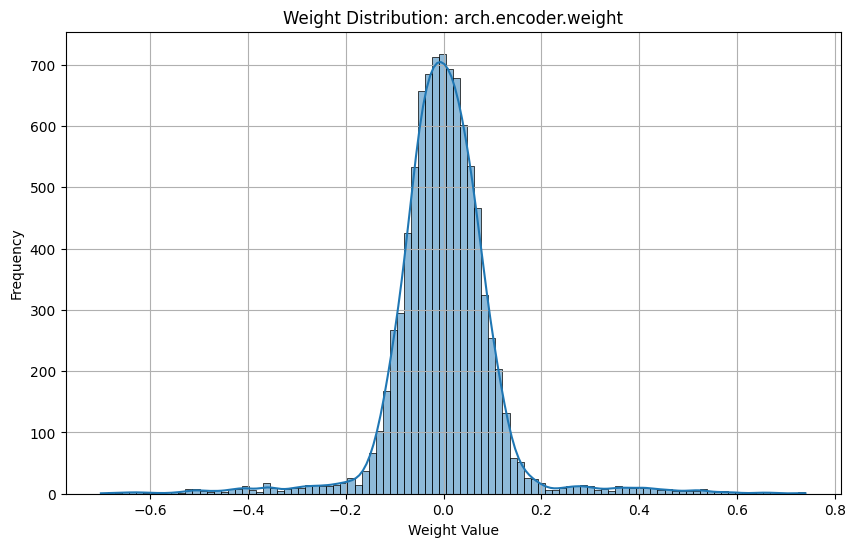

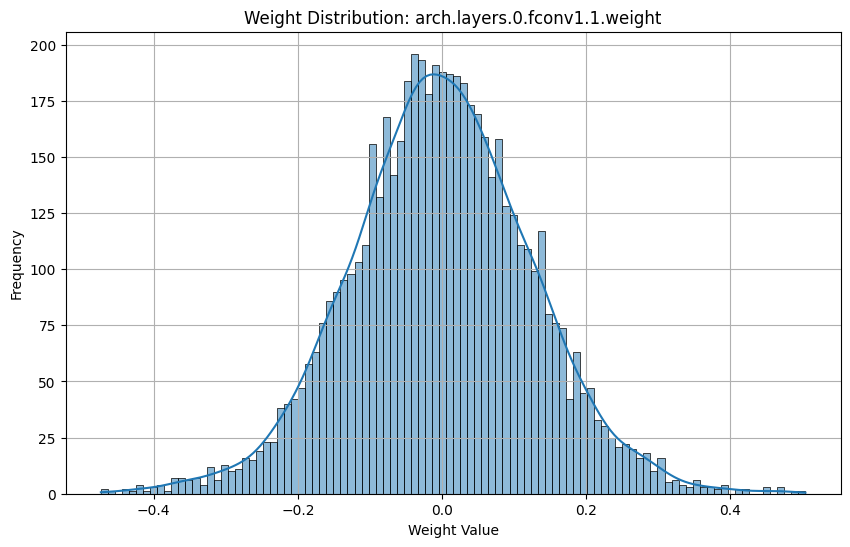

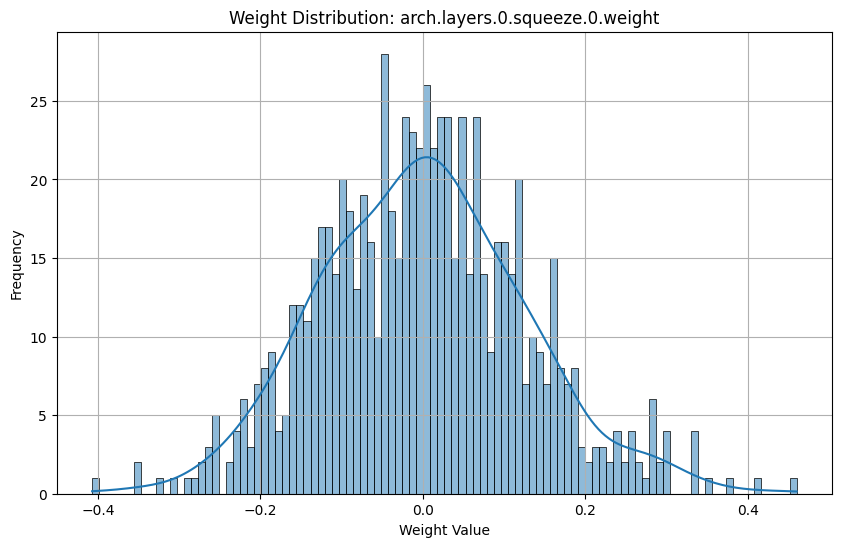

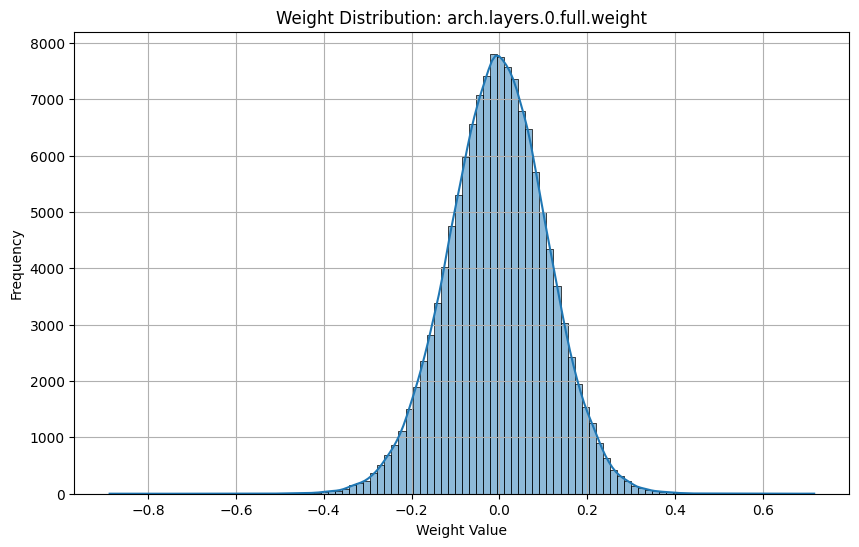

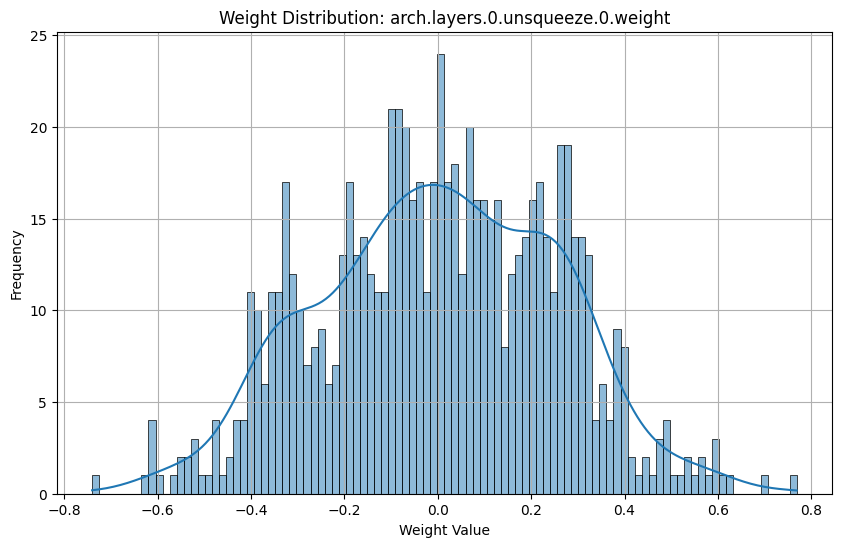

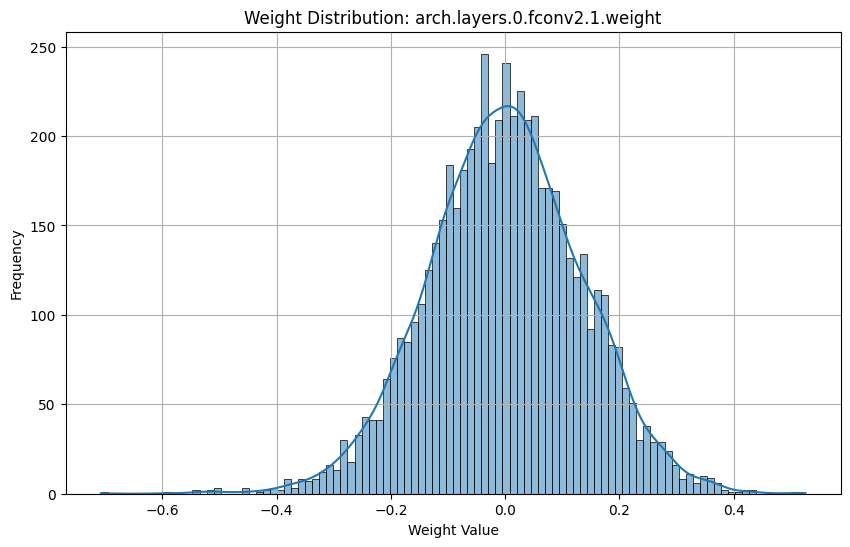

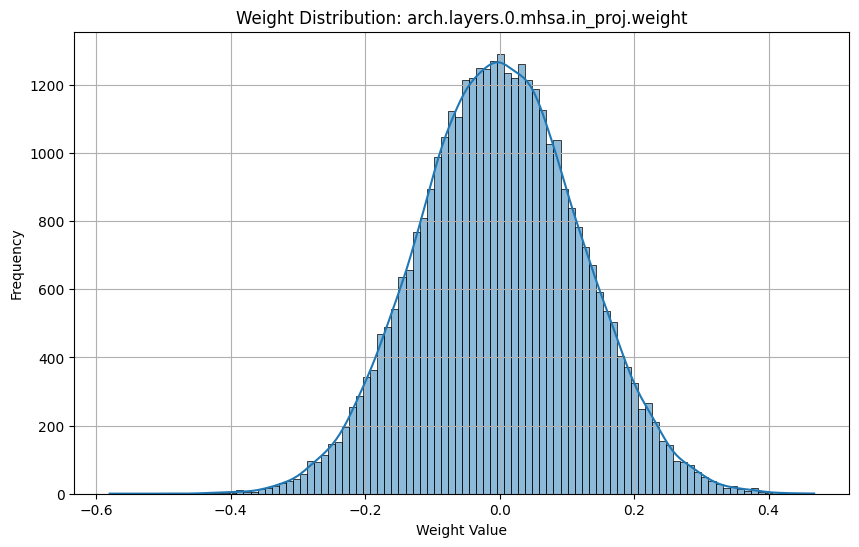

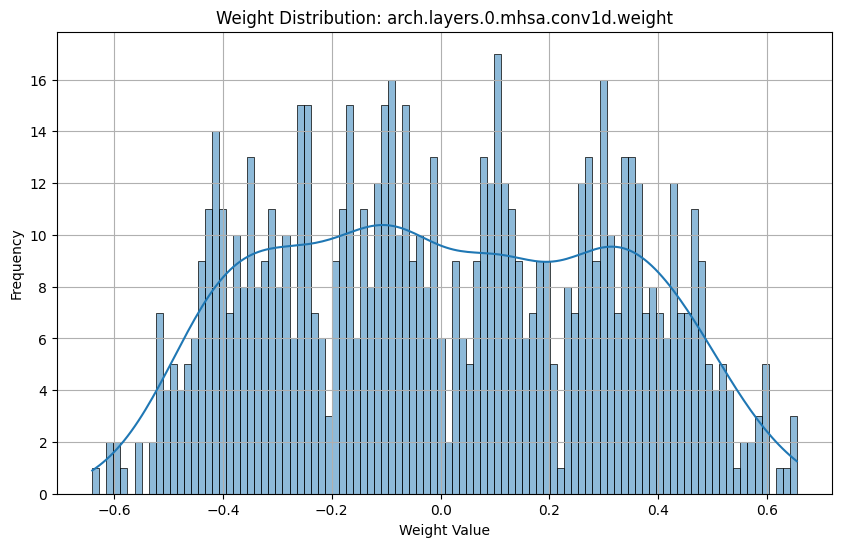

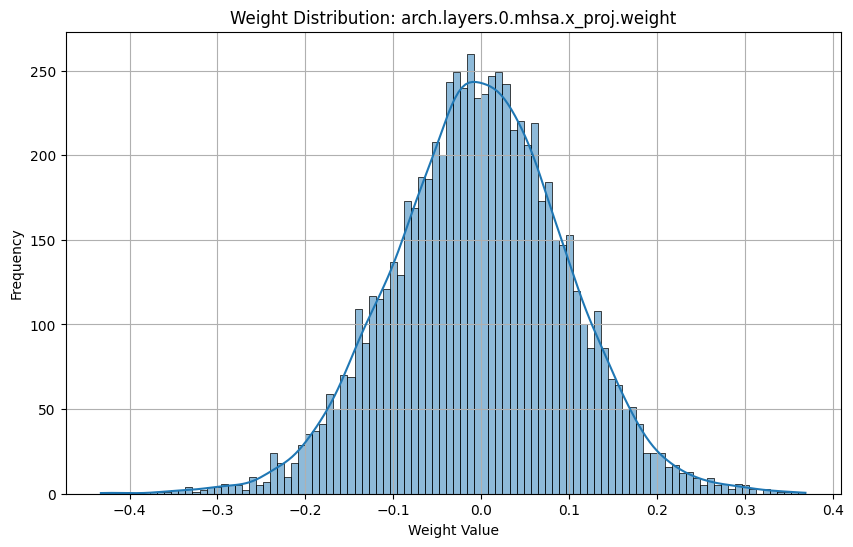

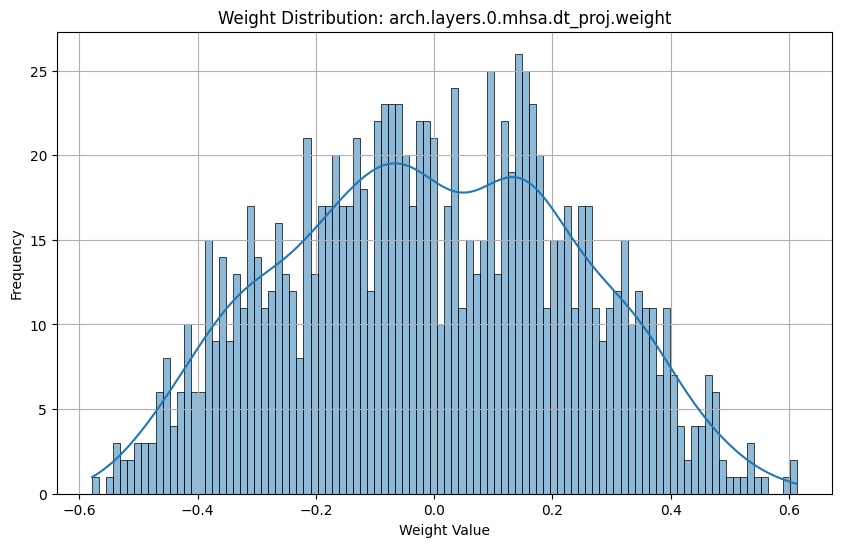

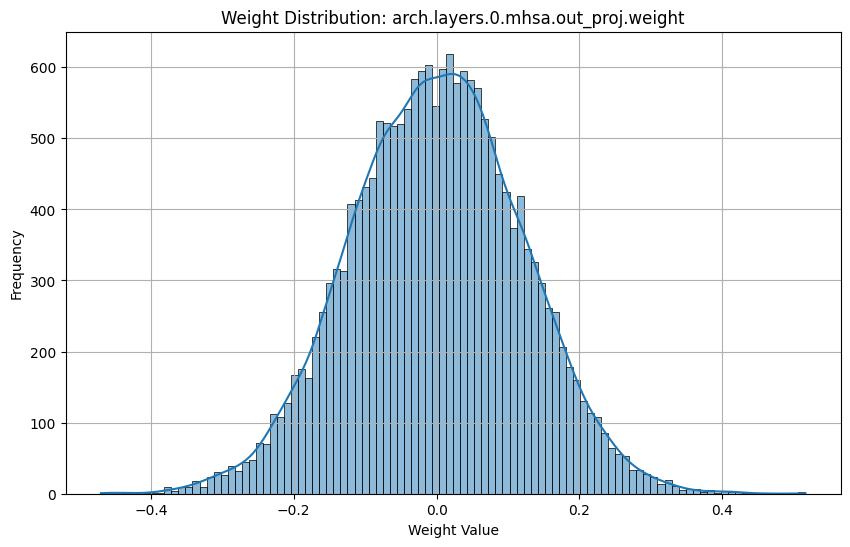

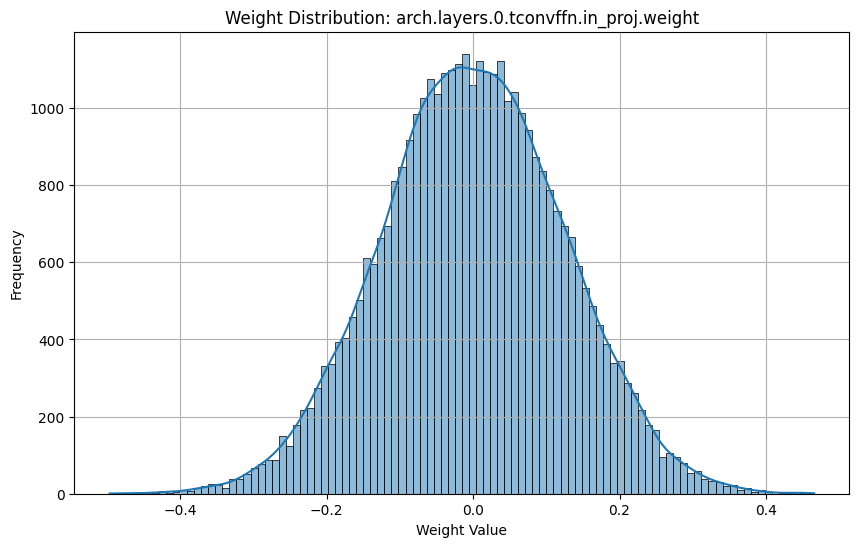

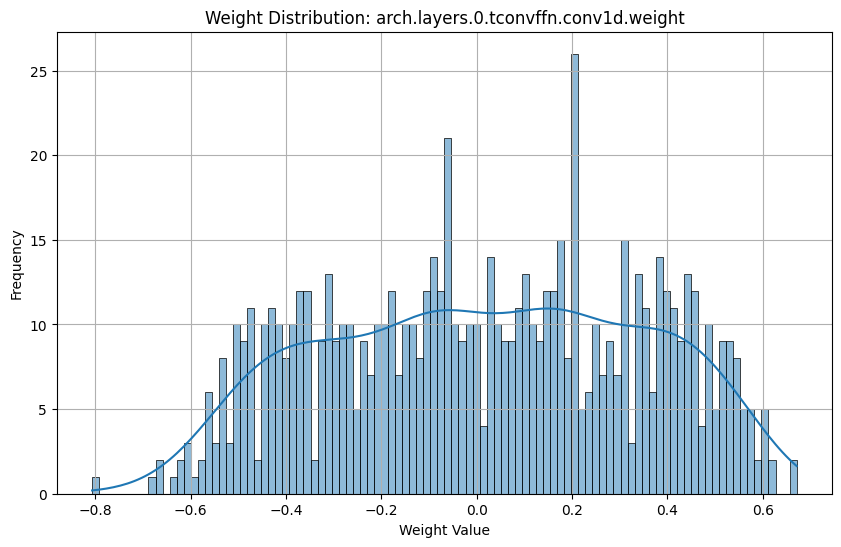

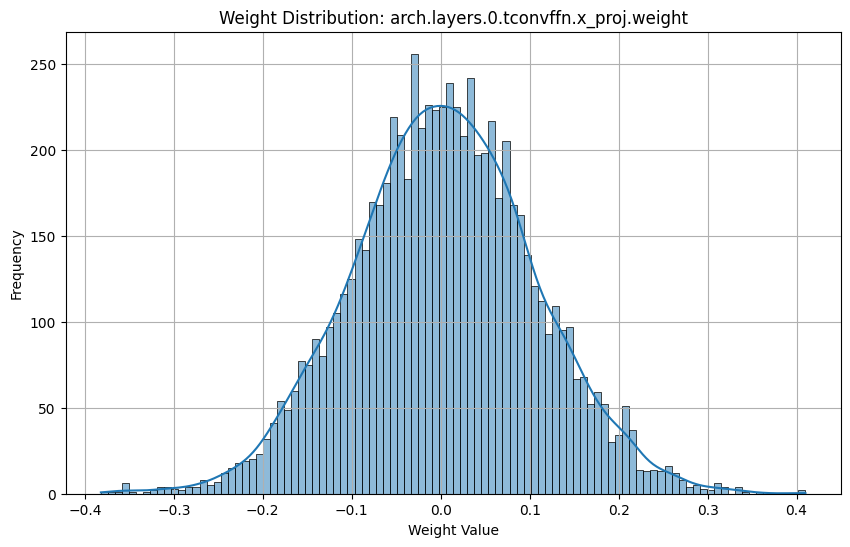

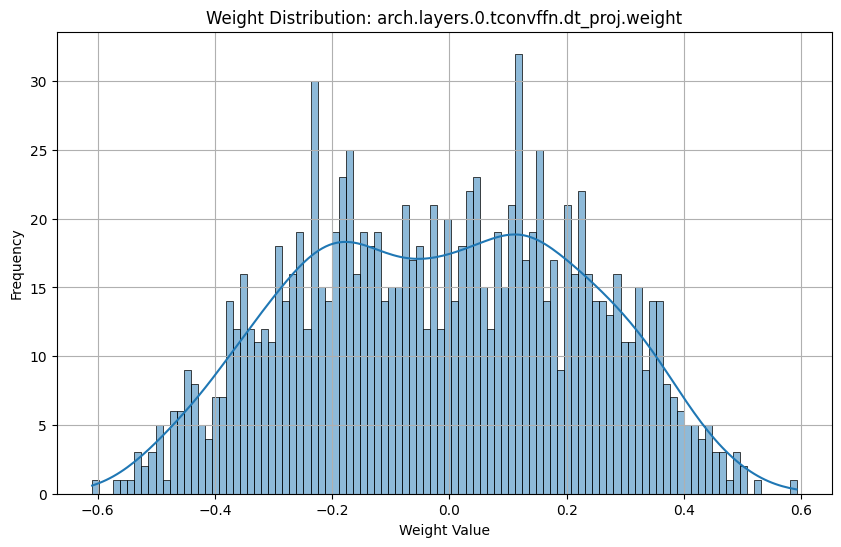

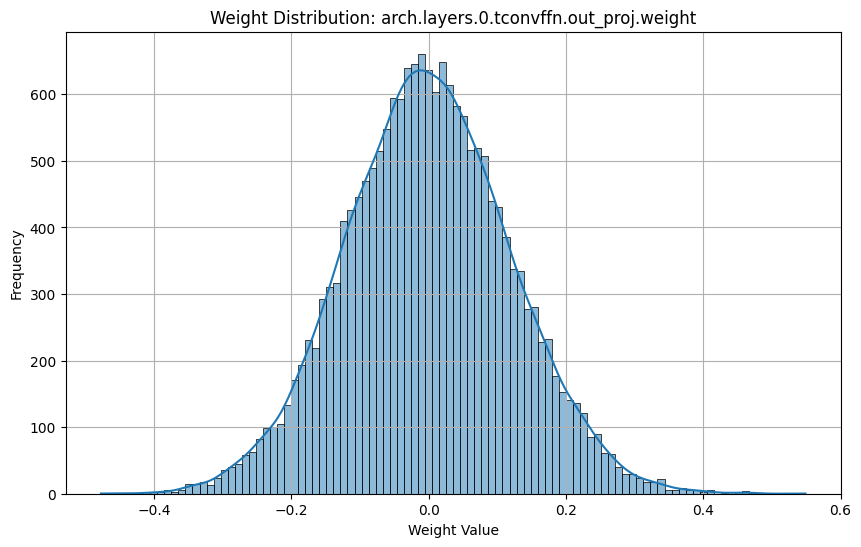

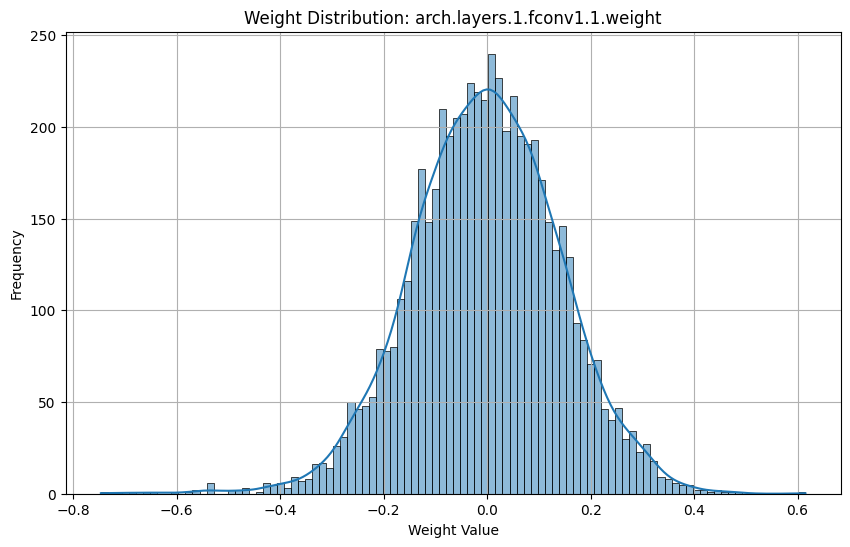

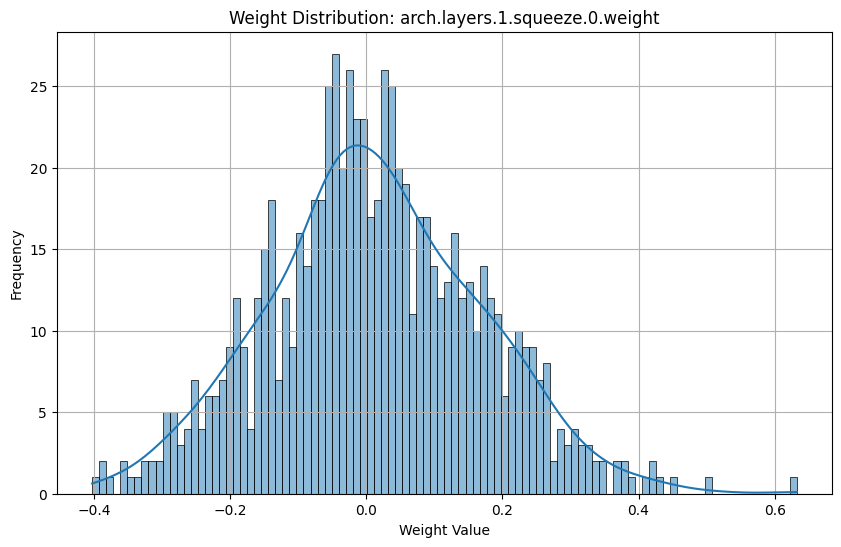

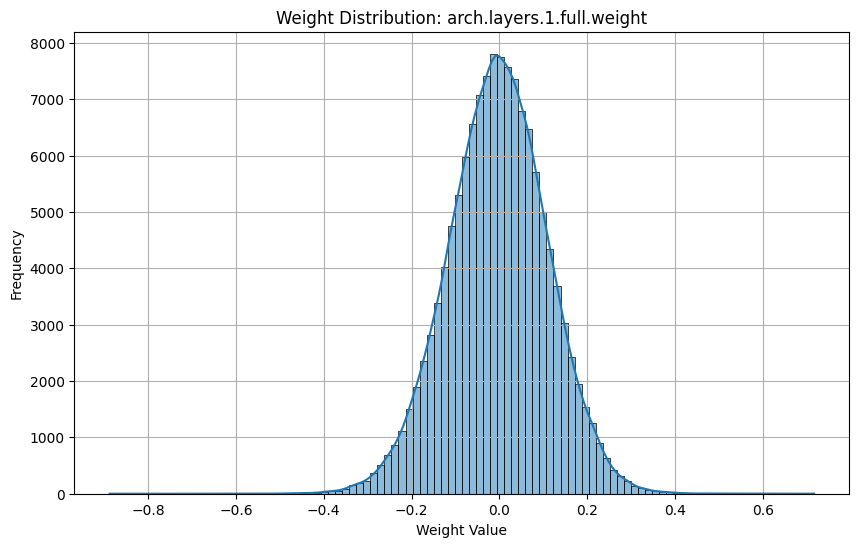

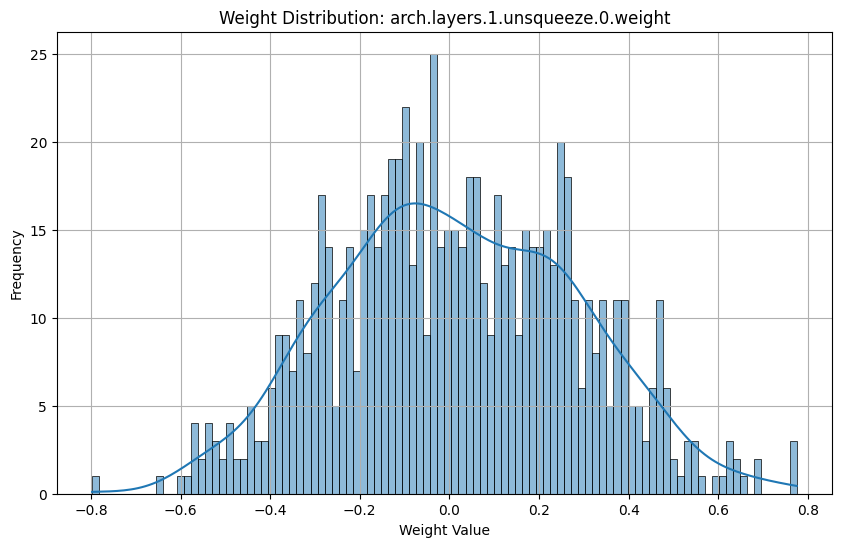

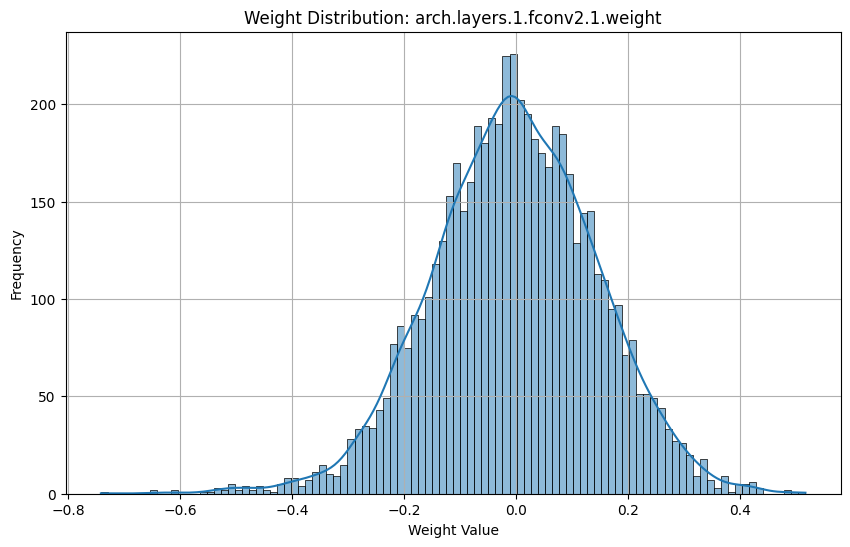

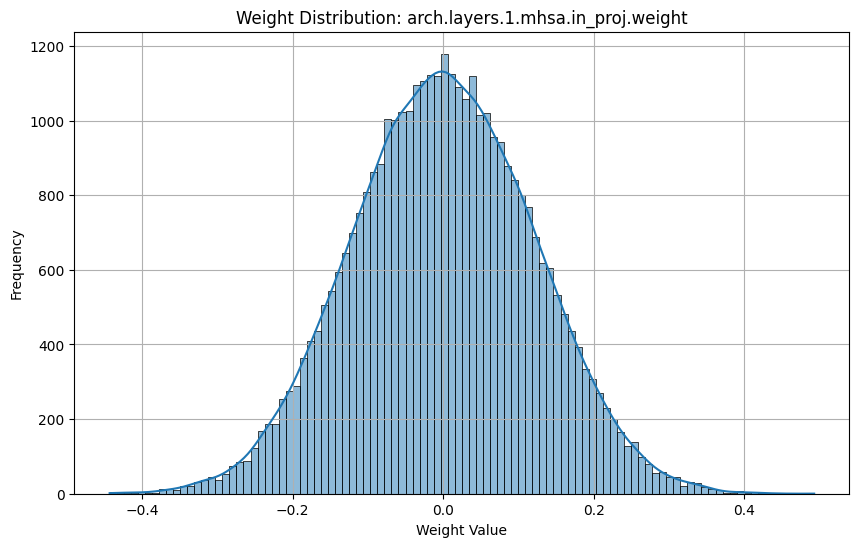

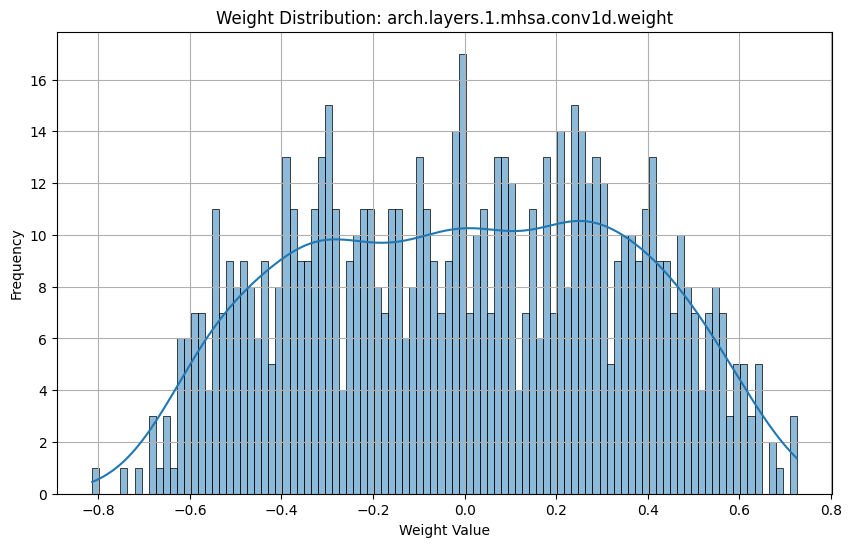

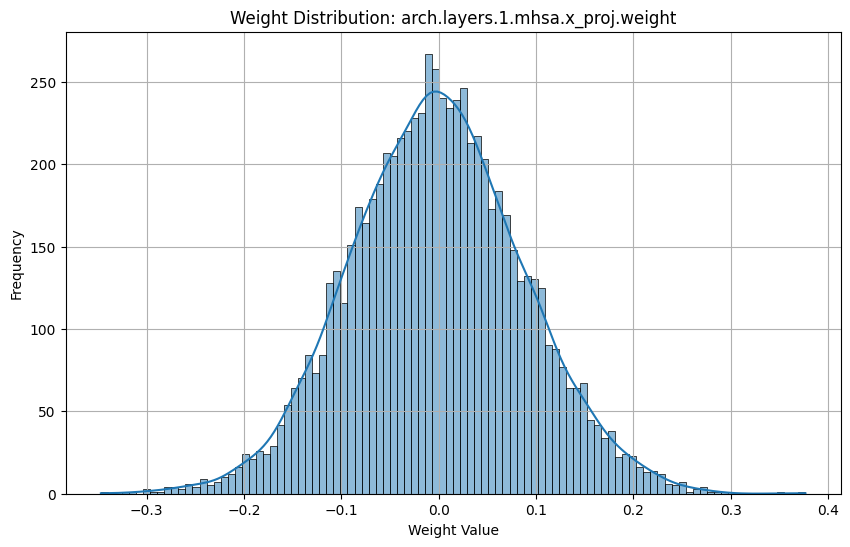

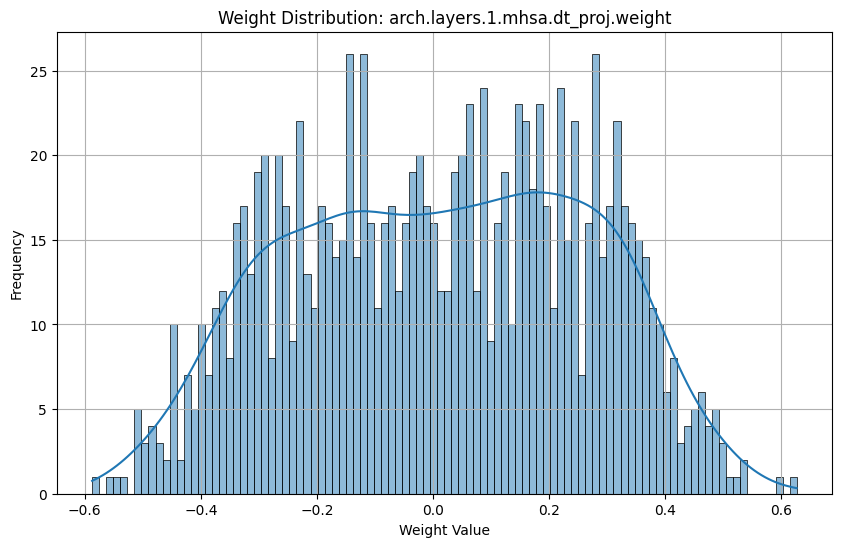

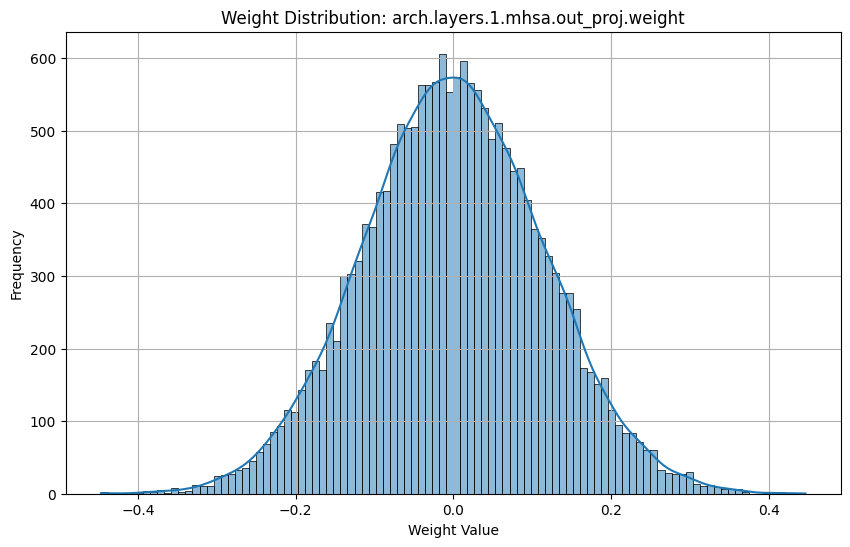

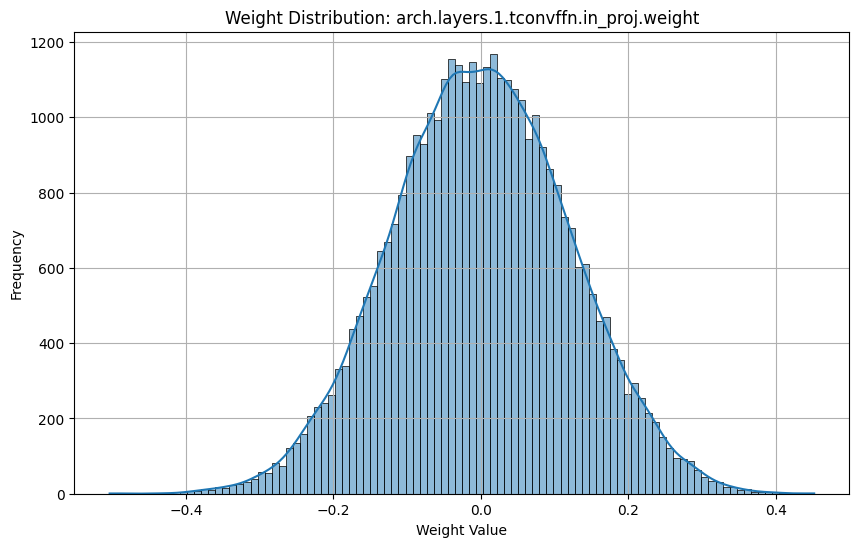

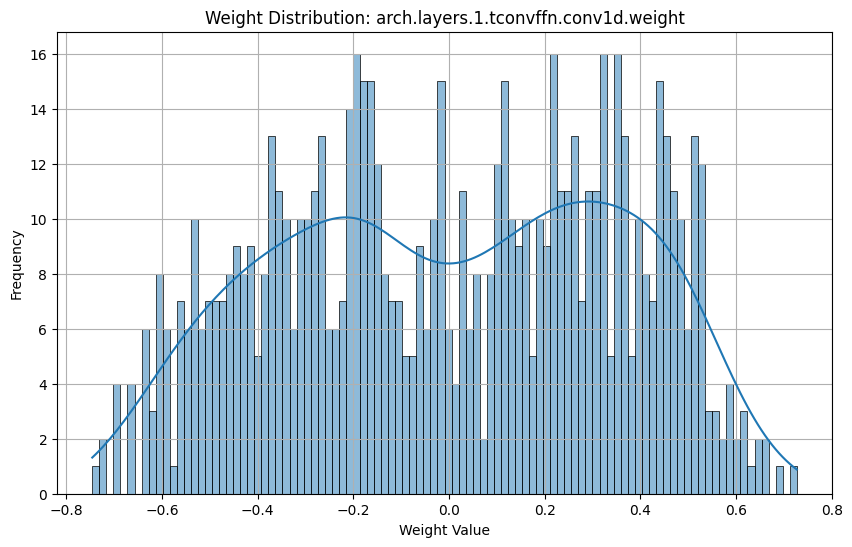

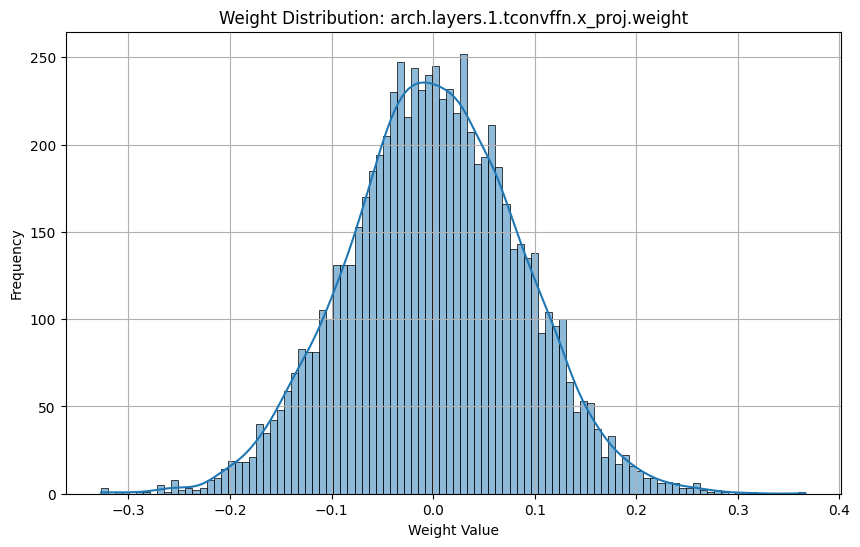

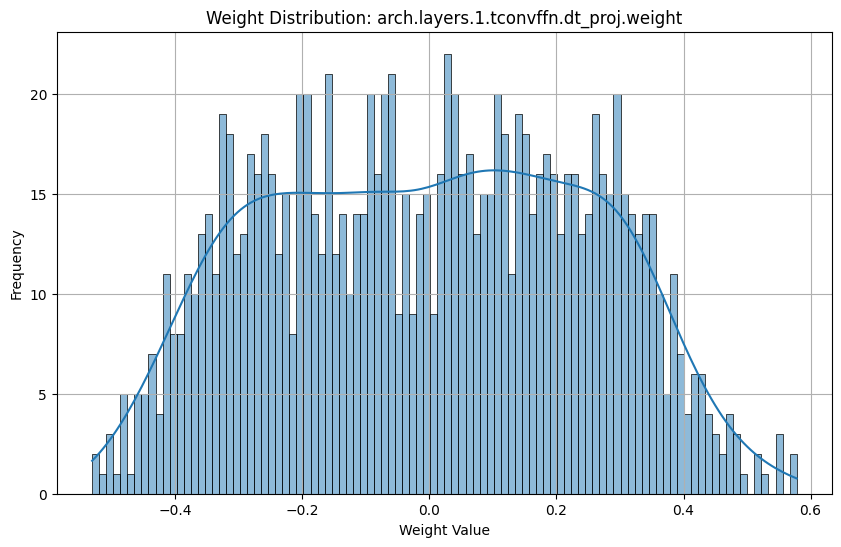

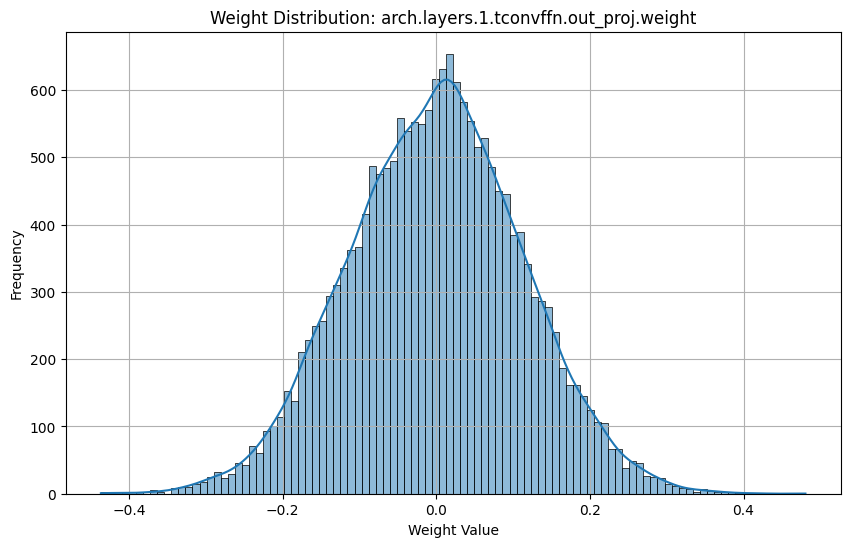

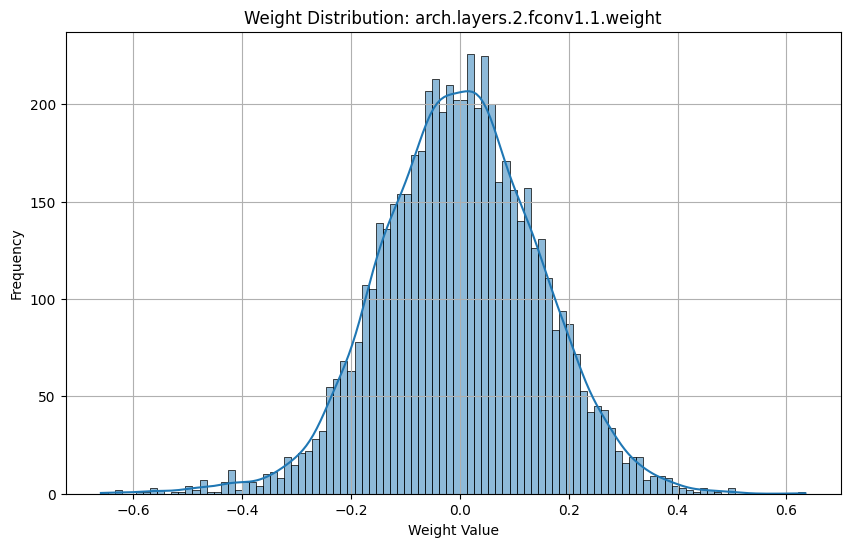

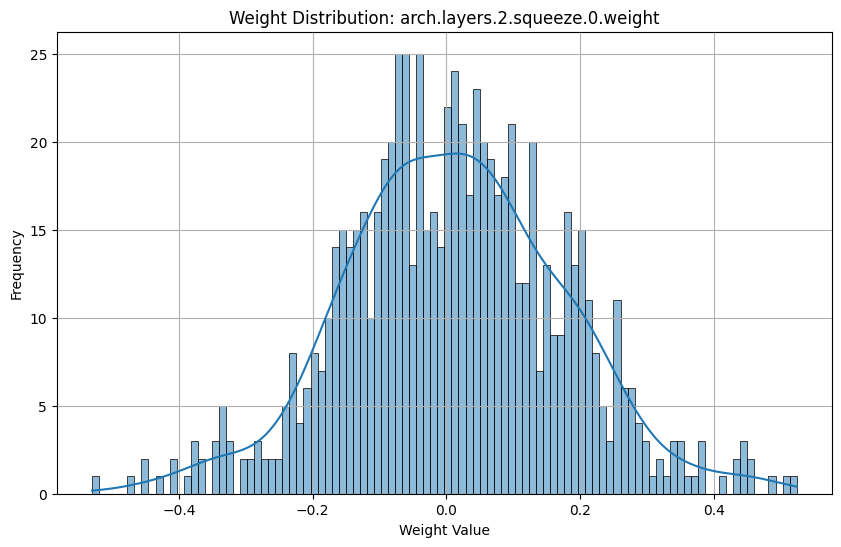

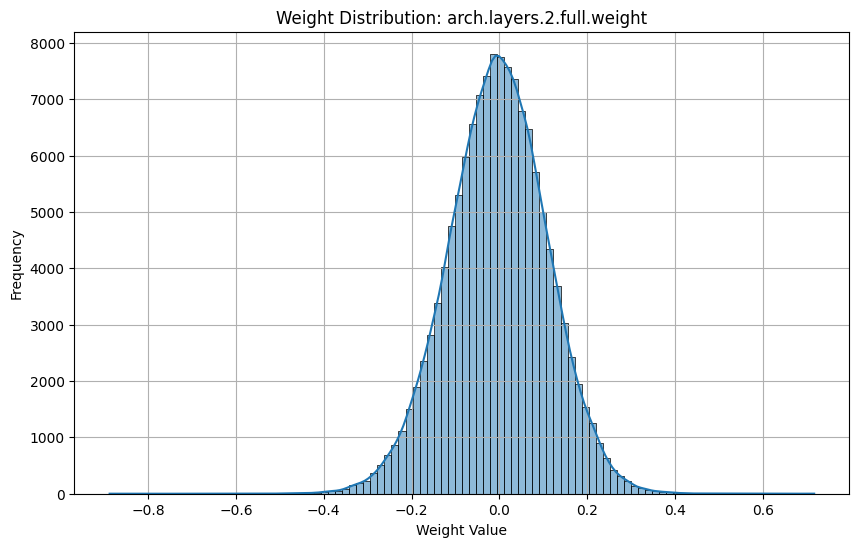

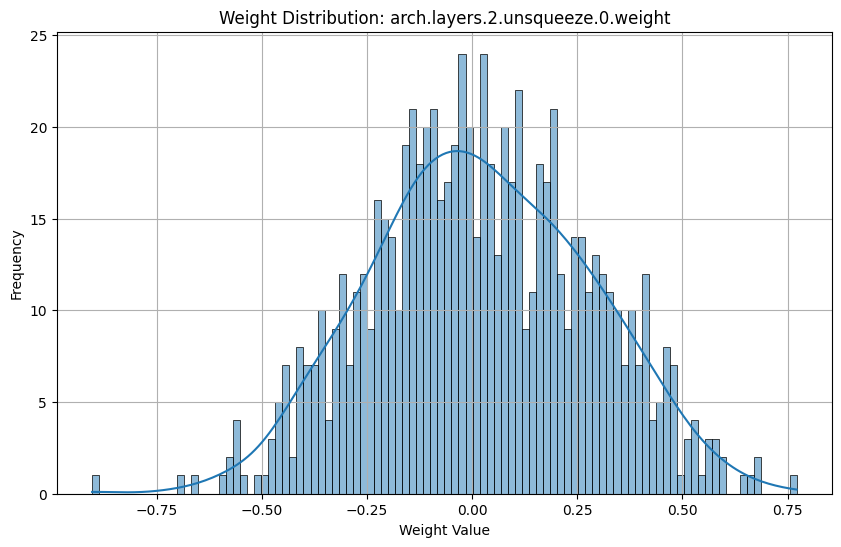

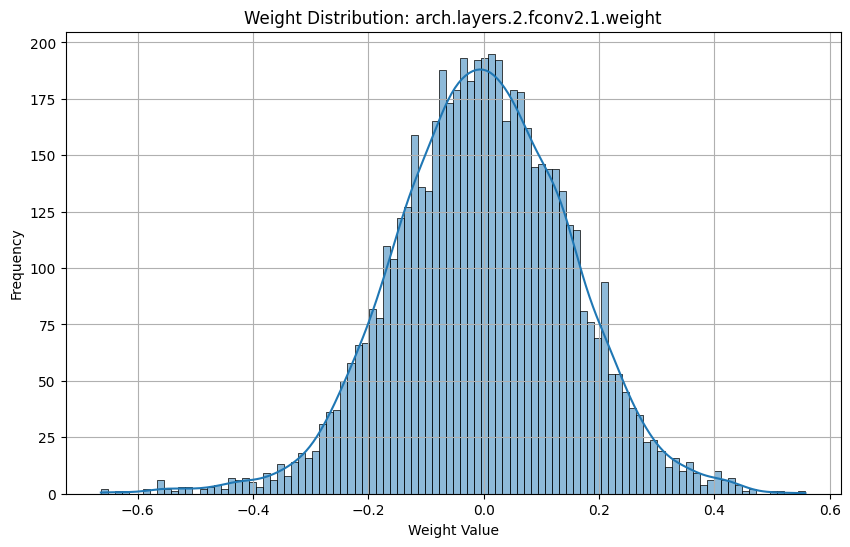

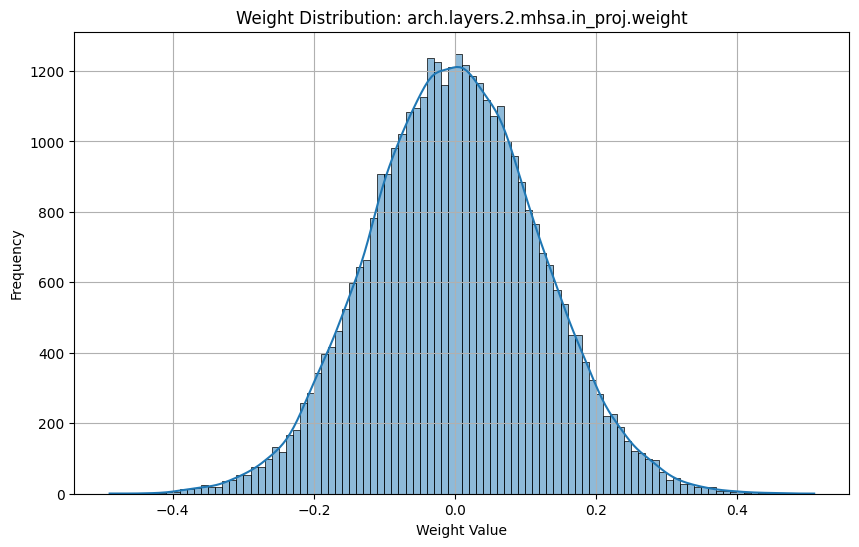

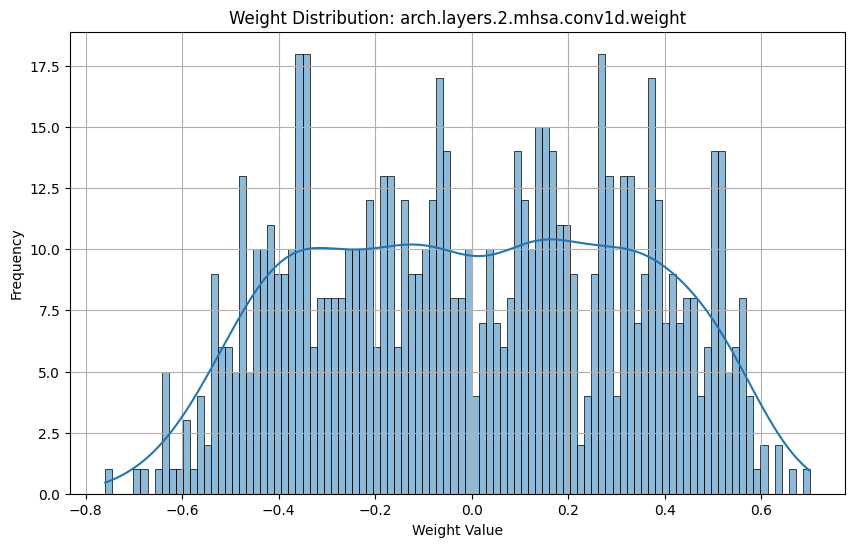

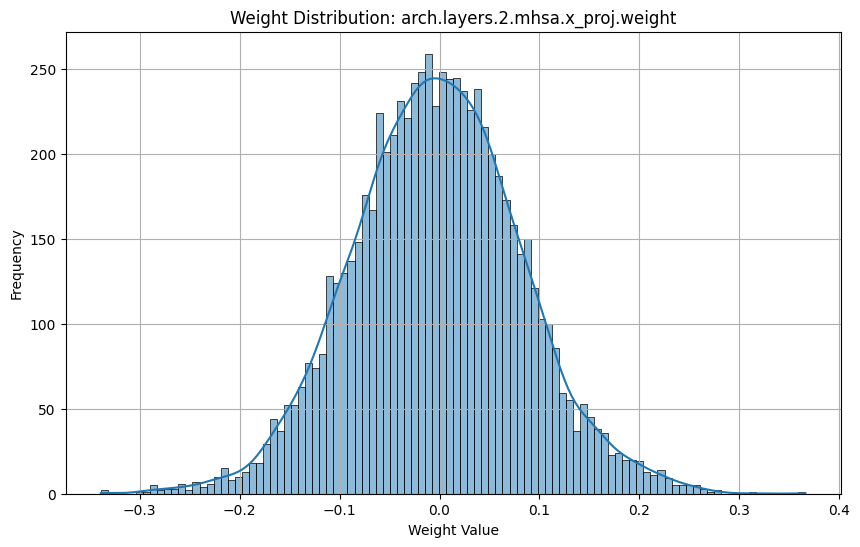

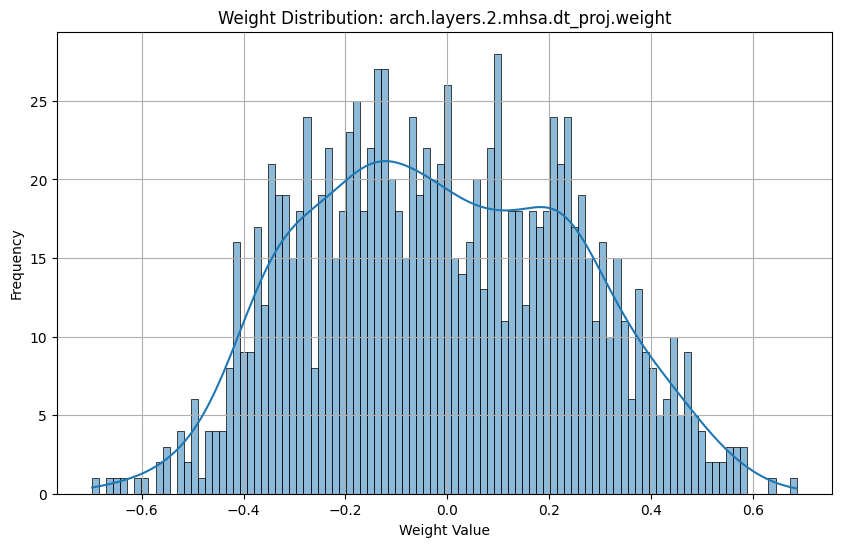

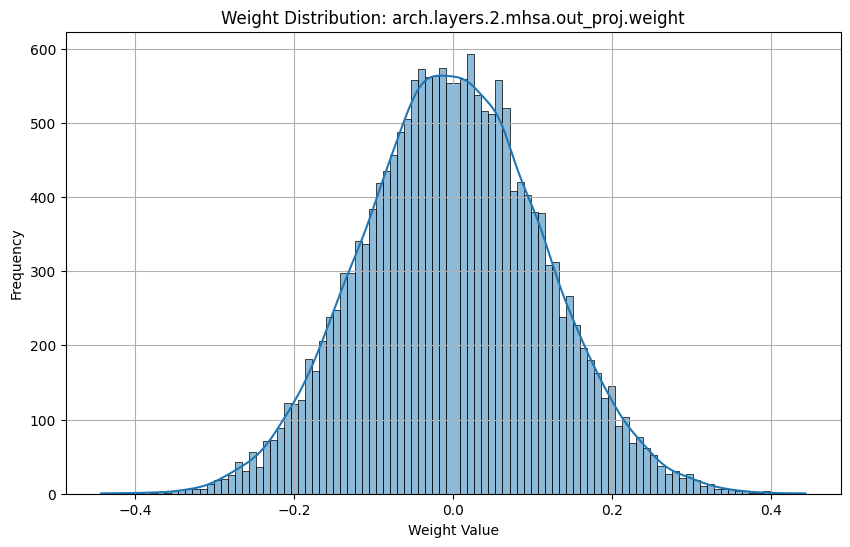

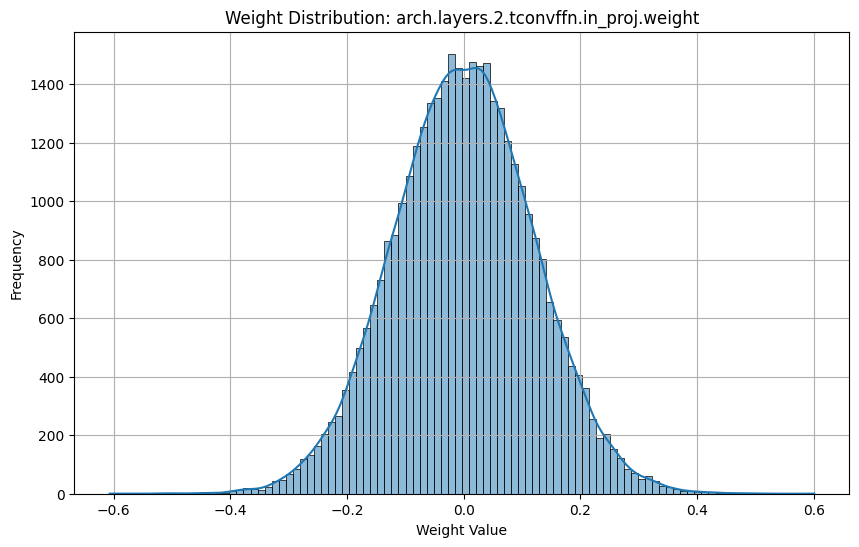

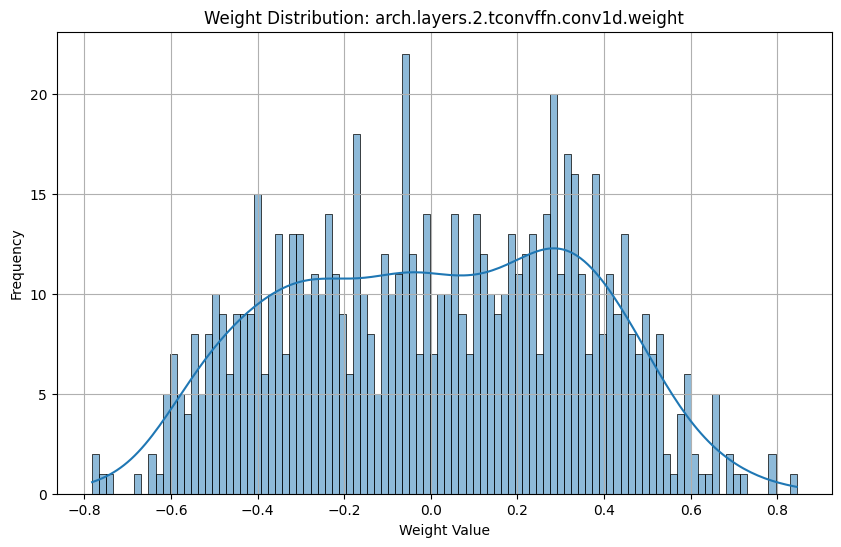

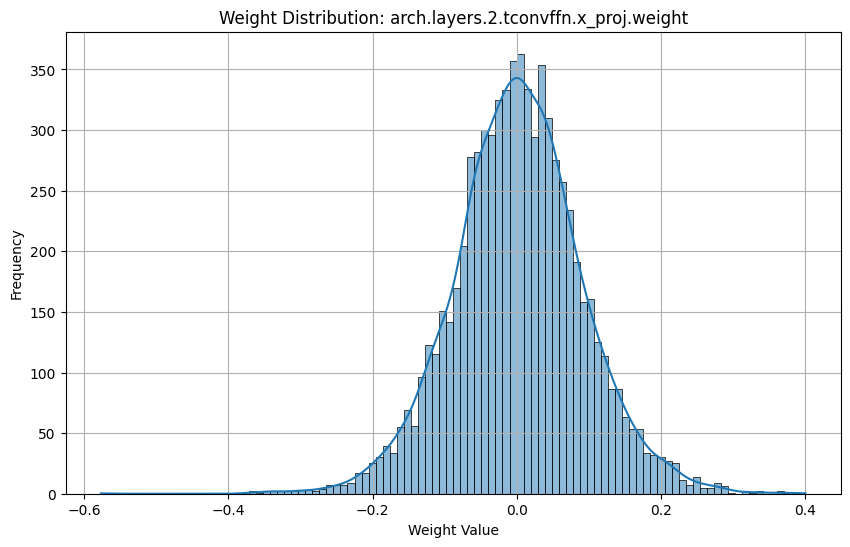

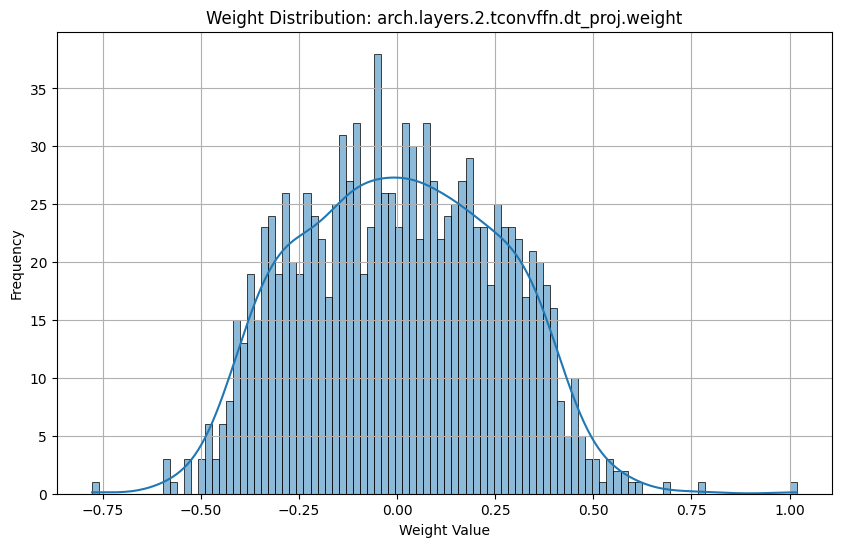

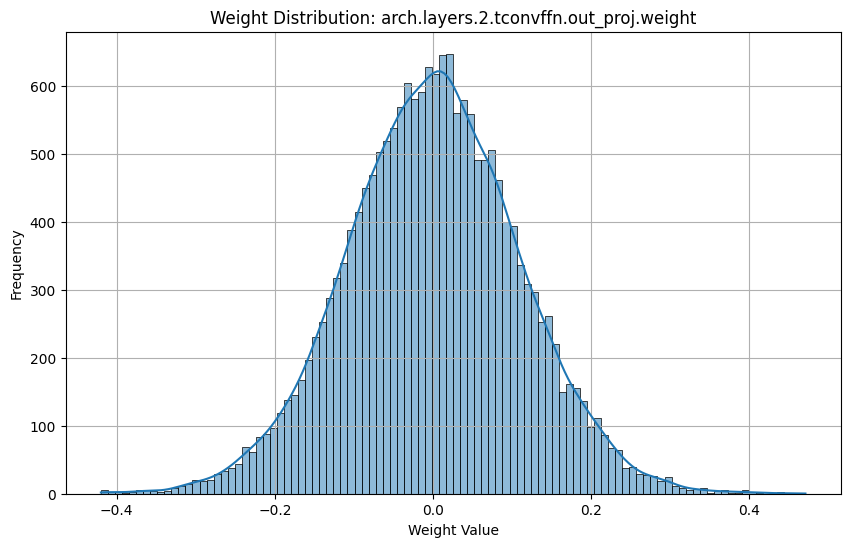

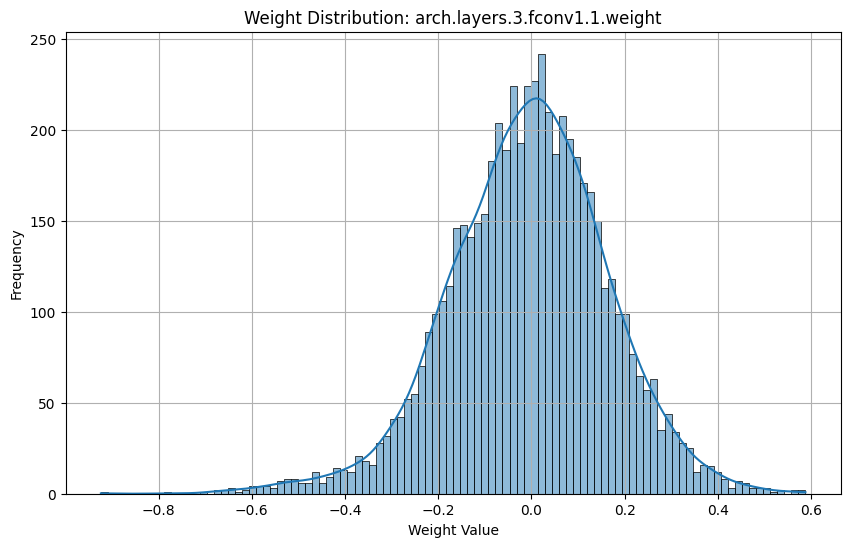

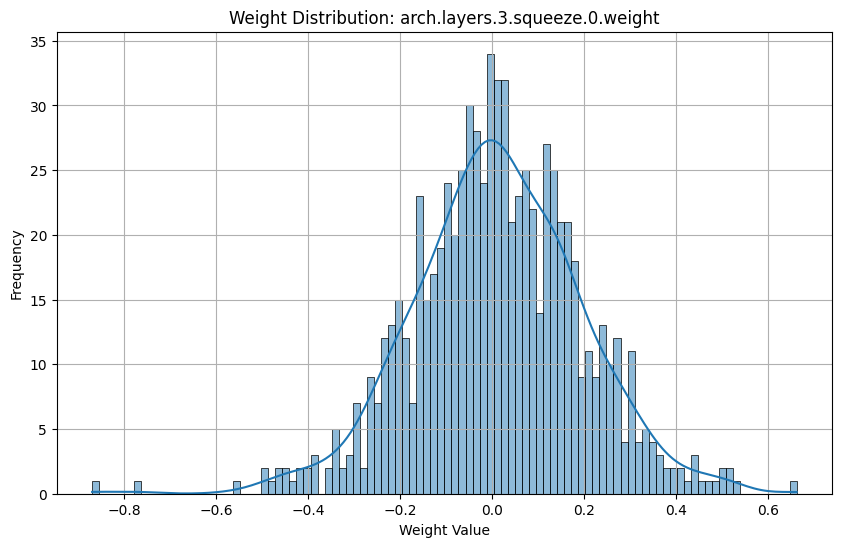

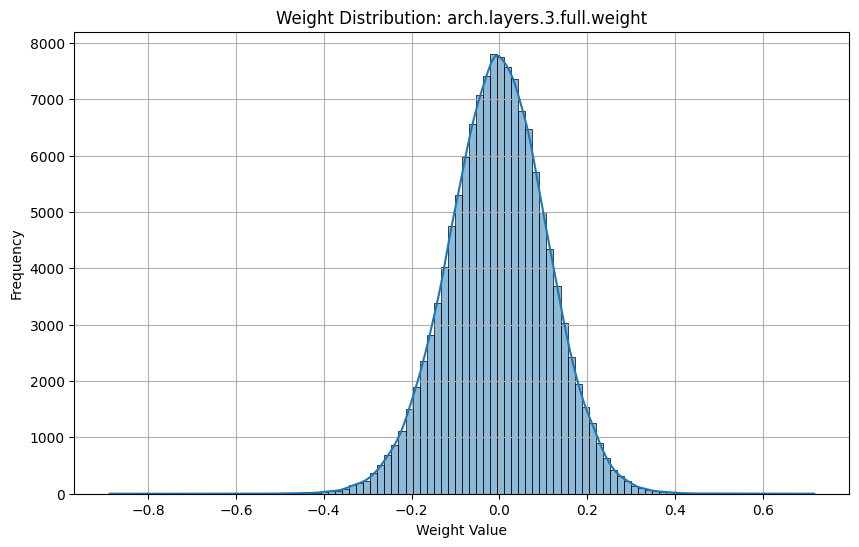

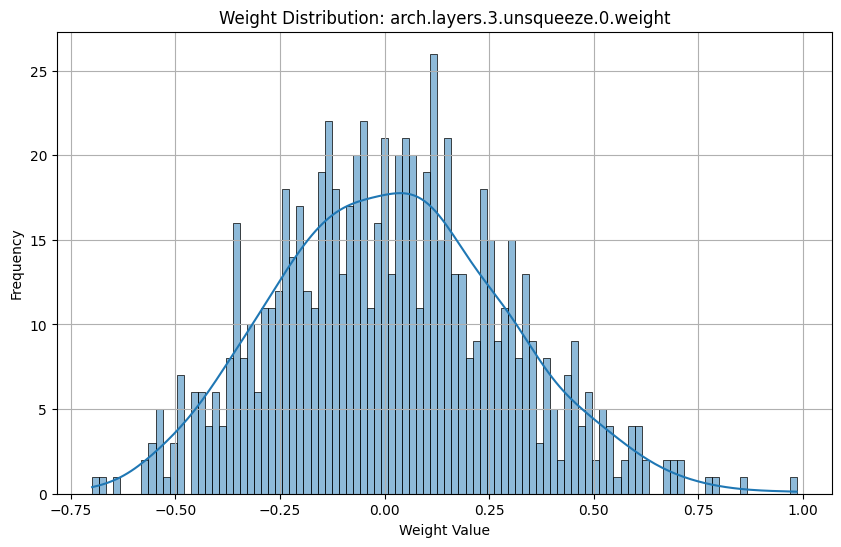

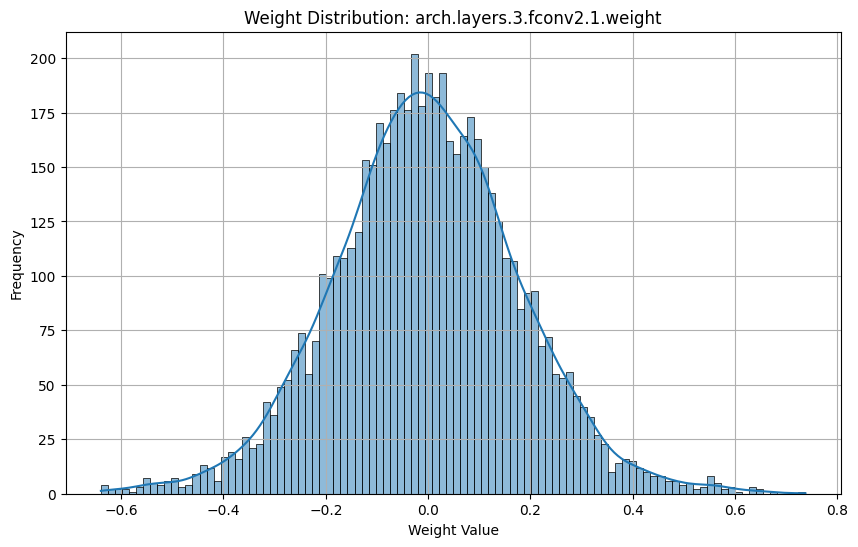

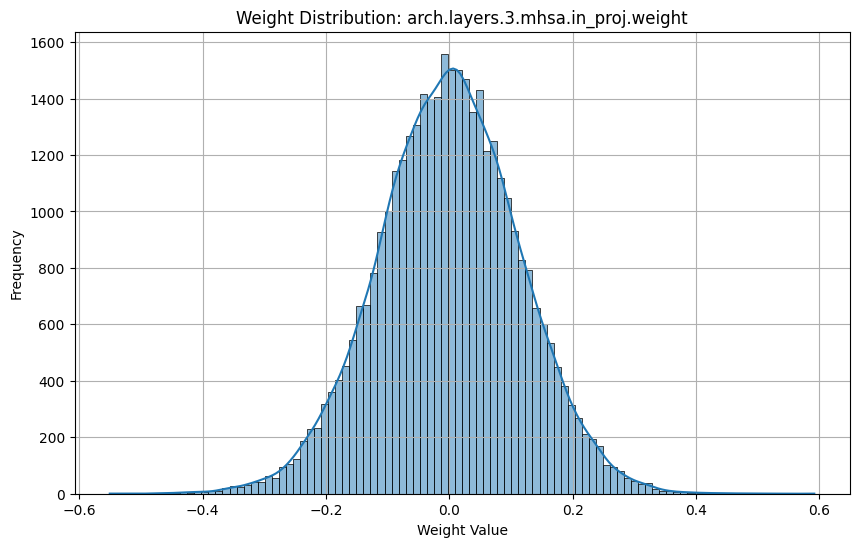

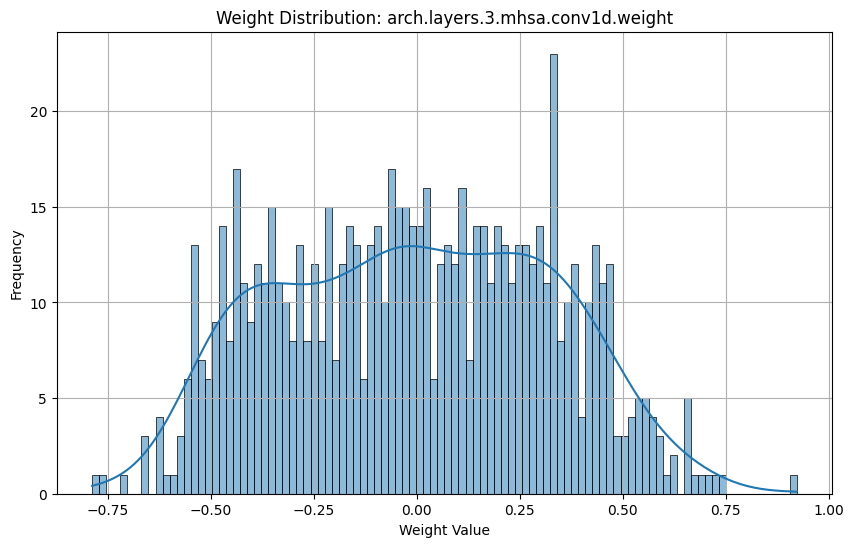

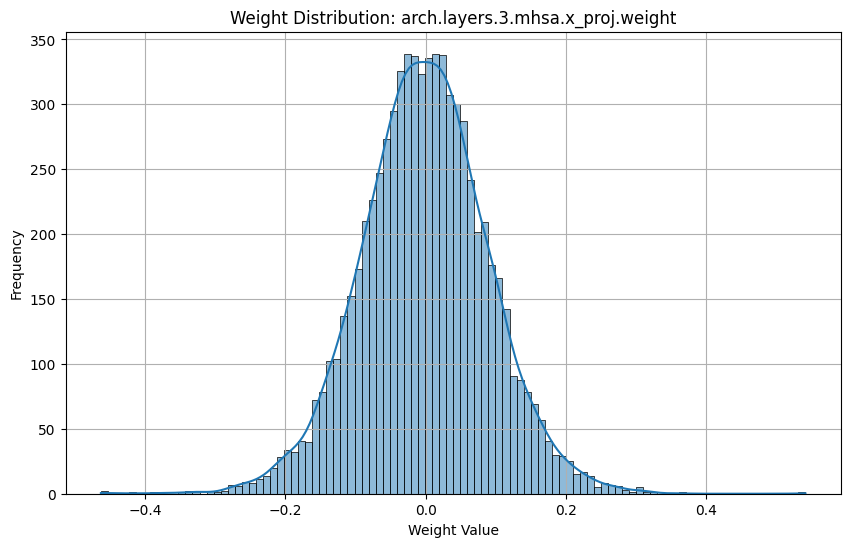

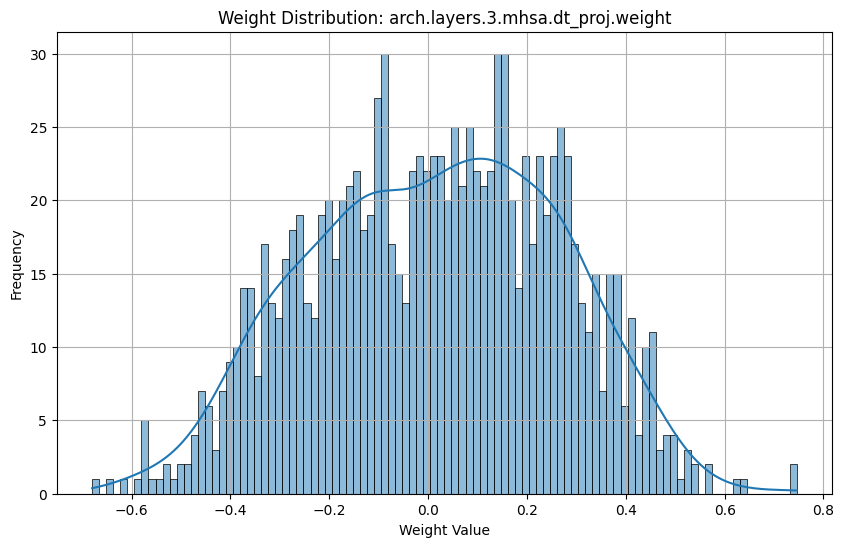

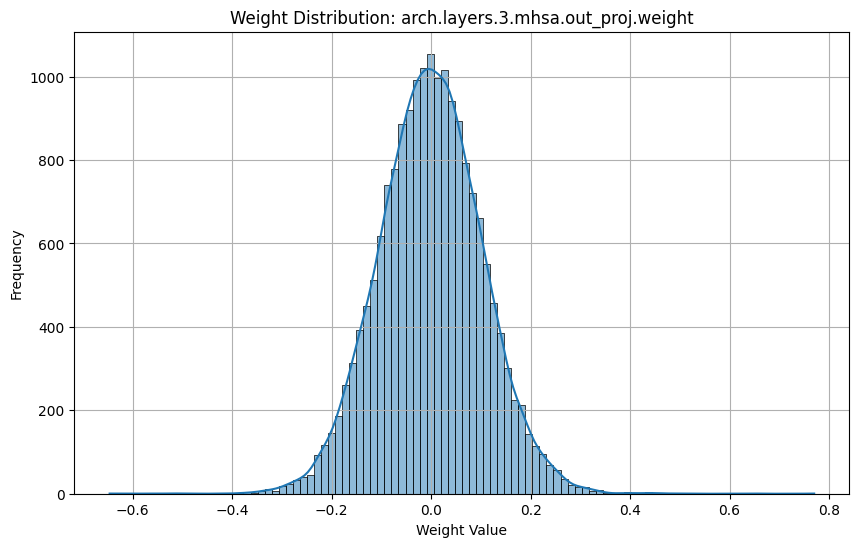

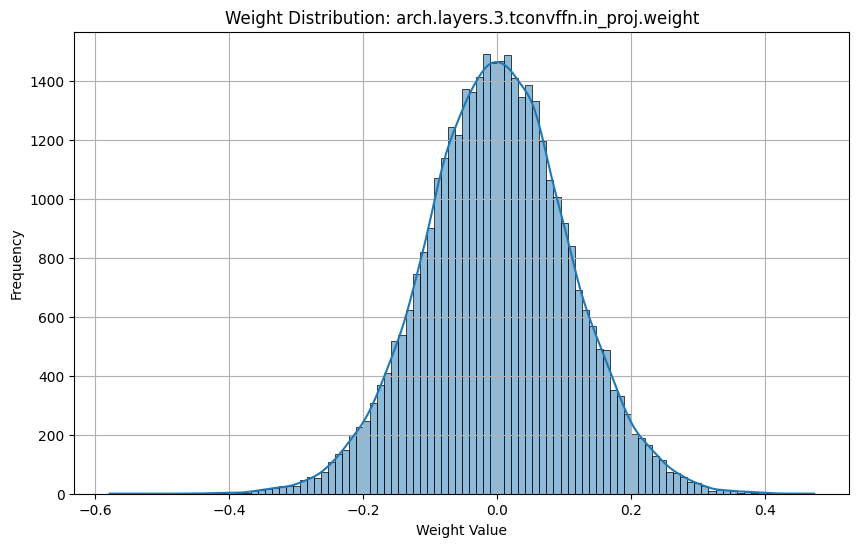

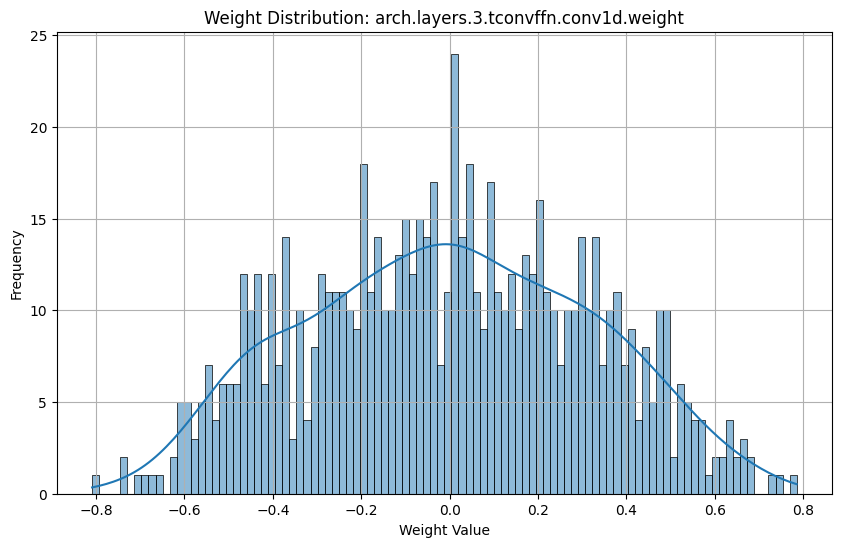

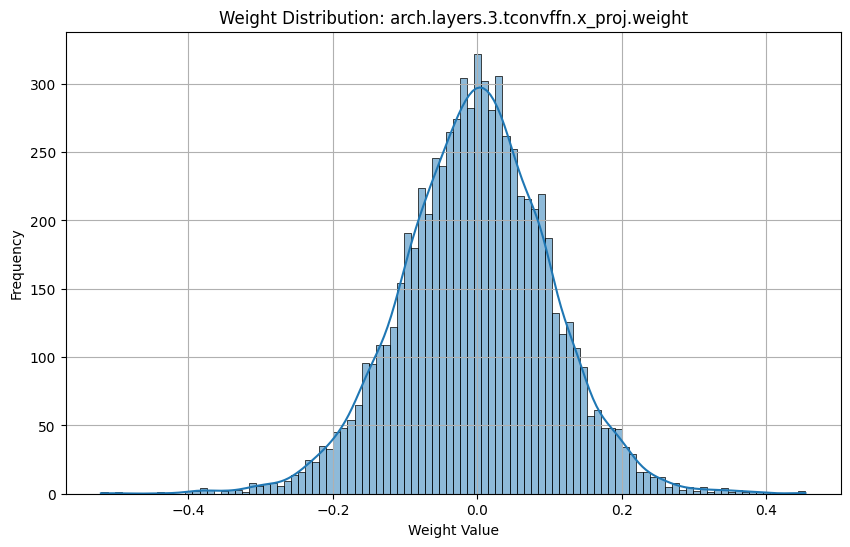

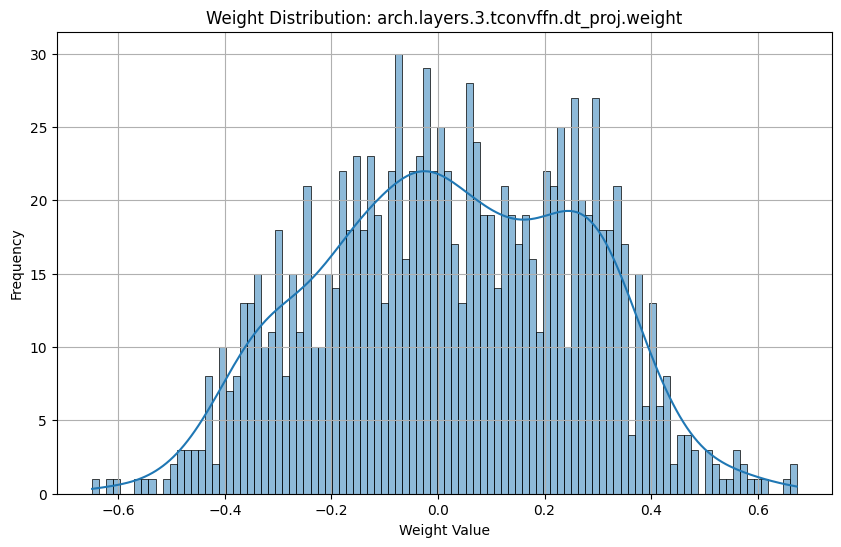

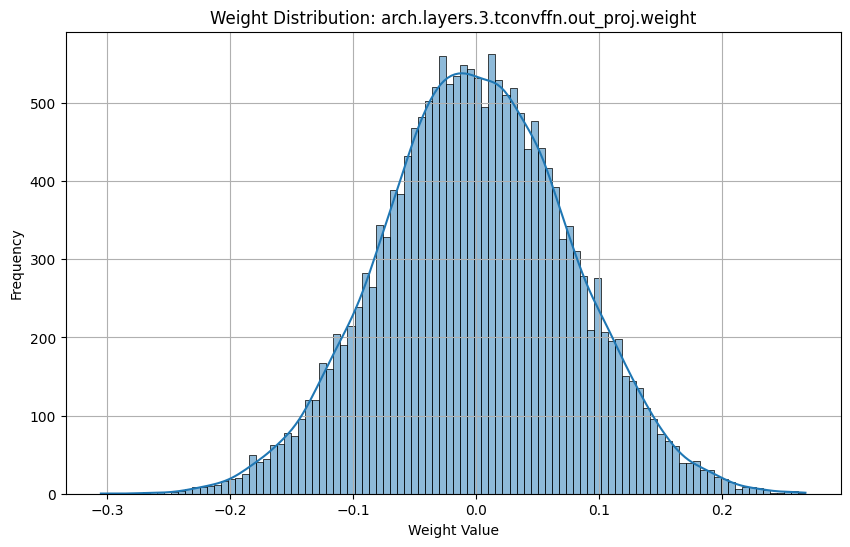

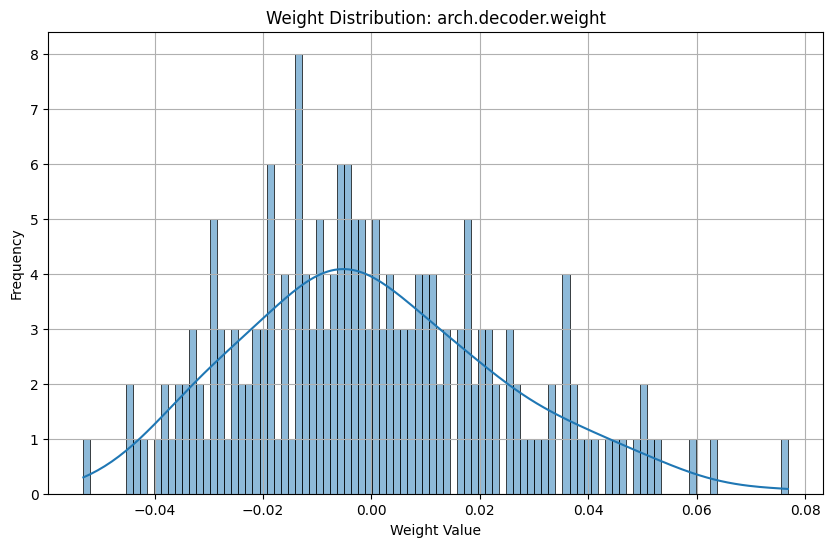

arch.encoder.weight: Mean=-0.0001, Std=0.1072, Min=-0.7003, Max=0.7397
arch.layers.0.fconv1.1.weight: Mean=-0.0014, Std=0.1264, Min=-0.4731, Max=0.5040
arch.layers.0.squeeze.0.weight: Mean=-0.0002, Std=0.1264, Min=-0.4070, Max=0.4603
arch.layers.0.full.weight: Mean=-0.0036, Std=0.1128, Min=-0.8875, Max=0.7167
arch.layers.0.unsqueeze.0.weight: Mean=0.0025, Std=0.2519, Min=-0.7406, Max=0.7688
arch.layers.0.fconv2.1.weight: Mean=-0.0008, Std=0.1339, Min=-0.7077, Max=0.5257
arch.layers.0.mhsa.in_proj.weight: Mean=0.0000, Std=0.1191, Min=-0.5800, Max=0.4679
arch.layers.0.mhsa.conv1d.weight: Mean=0.0087, Std=0.3054, Min=-0.6400, Max=0.6544
arch.layers.0.mhsa.x_proj.weight: Mean=-0.0021, Std=0.0983, Min=-0.4326, Max=0.3688
arch.layers.0.mhsa.dt_proj.weight: Mean=-0.0048, Std=0.2431, Min=-0.5784, Max=0.6130
arch.layers.0.mhsa.out_proj.weight: Mean=-0.0002, Std=0.1194, Min=-0.4699, Max=0.5163
arch.layers.0.tconvffn.in_proj.weight: Mean=-0.0001, Std=0.1243, Min=-0.4966, Max=0.4659
arch.layers.0.

In [1]:

# Install necessary libraries if not already installed
# !pip install torch pytorch-lightning matplotlib seaborn

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pytorch_lightning import LightningModule

# Load the checkpoint
checkpoint_path = "/mnt/audias_data/users/iazakaria/NBSS/logs/OnlineSpatialNet/version_33/checkpoints/epoch39_metric1.3285.ckpt"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Extract model weights
state_dict = checkpoint['state_dict']

# Initialize a dictionary to store weight distributions
weight_distributions = {}

# Iterate through the state_dict to collect weights
for name, param in state_dict.items():
    if "weight" in name and param.ndim > 1:  # Focus on weight tensors
        weight_distributions[name] = param.flatten().numpy()

# Plot weight distributions
for name, weights in weight_distributions.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(weights, bins=100, kde=True)
    plt.title(f"Weight Distribution: {name}")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Print summary of weights
for name, weights in weight_distributions.items():
    print(f"{name}: Mean={weights.mean():.4f}, Std={weights.std():.4f}, Min={weights.min():.4f}, Max={weights.max():.4f}")

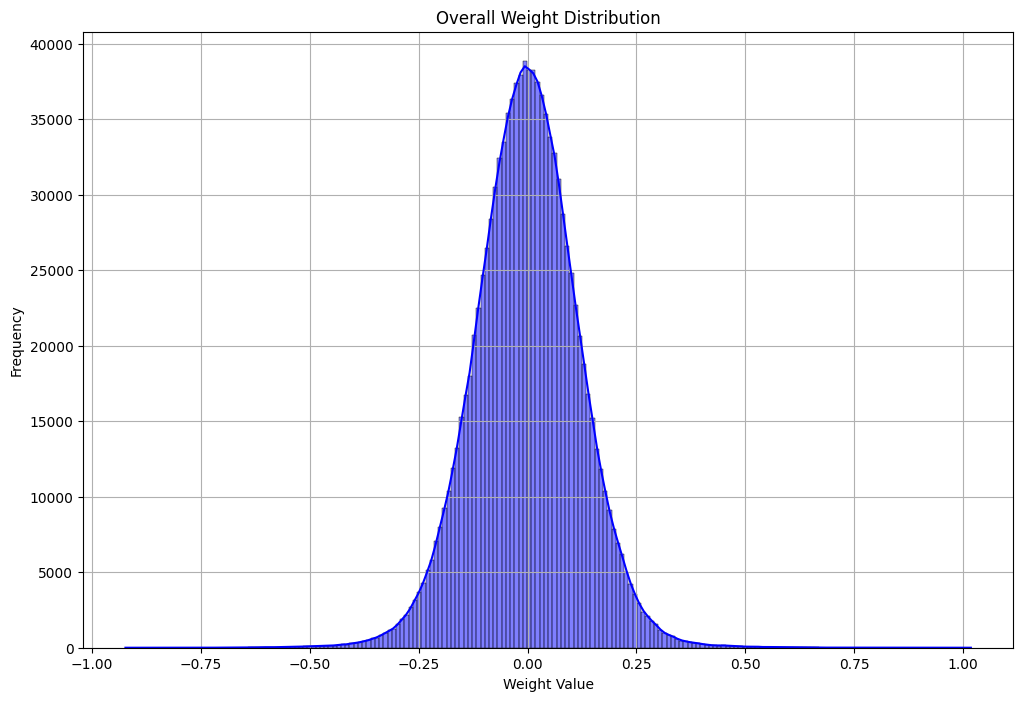

Overall Weights: Mean=-0.0018, Std=0.1195, Min=-0.9237, Max=1.0179


In [2]:
# Combine all weights into a single array for overall distribution
all_weights = []

for weights in weight_distributions.values():
    all_weights.extend(weights)

# Convert to a numpy array
all_weights = torch.tensor(all_weights).numpy()

# Plot the overall weight distribution
plt.figure(figsize=(12, 8))
sns.histplot(all_weights, bins=200, kde=True, color='blue')
plt.title("Overall Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Print summary of overall weights
print(f"Overall Weights: Mean={all_weights.mean():.4f}, Std={all_weights.std():.4f}, Min={all_weights.min():.4f}, Max={all_weights.max():.4f}")

In [3]:
# Extract PReLU parameters
prelu_distributions = {}

for name, param in state_dict.items():
    if "PReLU" in name:  # Look for PReLU layers
        prelu_distributions[name] = param.flatten().numpy()

# Plot PReLU parameter distributions
for name, prelu_params in prelu_distributions.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(prelu_params, bins=50, kde=True, color='orange')
    plt.title(f"PReLU Parameter Distribution: {name}")
    plt.xlabel("PReLU Parameter Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Print summary of PReLU parameters
for name, prelu_params in prelu_distributions.items():
    print(f"{name}: Mean={prelu_params.mean():.4f}, Std={prelu_params.std():.4f}, Min={prelu_params.min():.4f}, Max={prelu_params.max():.4f}")

In [4]:
print(state_dict.keys())

odict_keys(['arch.encoder.weight', 'arch.encoder.bias', 'arch.layers.0.fconv1.0.weight', 'arch.layers.0.fconv1.0.bias', 'arch.layers.0.fconv1.1.weight', 'arch.layers.0.fconv1.1.bias', 'arch.layers.0.fconv1.2.weight', 'arch.layers.0.norm_full.weight', 'arch.layers.0.norm_full.bias', 'arch.layers.0.squeeze.0.weight', 'arch.layers.0.squeeze.0.bias', 'arch.layers.0.full.weight', 'arch.layers.0.full.bias', 'arch.layers.0.unsqueeze.0.weight', 'arch.layers.0.unsqueeze.0.bias', 'arch.layers.0.fconv2.0.weight', 'arch.layers.0.fconv2.0.bias', 'arch.layers.0.fconv2.1.weight', 'arch.layers.0.fconv2.1.bias', 'arch.layers.0.fconv2.2.weight', 'arch.layers.0.norm_mhsa.weight', 'arch.layers.0.norm_mhsa.bias', 'arch.layers.0.mhsa.A_log', 'arch.layers.0.mhsa.D', 'arch.layers.0.mhsa.in_proj.weight', 'arch.layers.0.mhsa.conv1d.weight', 'arch.layers.0.mhsa.conv1d.bias', 'arch.layers.0.mhsa.x_proj.weight', 'arch.layers.0.mhsa.dt_proj.weight', 'arch.layers.0.mhsa.dt_proj.bias', 'arch.layers.0.mhsa.out_proj.we

In [5]:
prelu_distributions = {}

for name, param in state_dict.items():
    if "PReLU" in name:  # Look for PReLU layers
        print(f"Found PReLU layer: {name}")
        prelu_distributions[name] = param.flatten().numpy()

if not prelu_distributions:
    print("No PReLU parameters found in the state_dict.")

No PReLU parameters found in the state_dict.


Found PReLU layer: arch.layers.0.fconv1.2.weight
Found PReLU layer: arch.layers.0.fconv2.2.weight
Found PReLU layer: arch.layers.1.fconv1.2.weight
Found PReLU layer: arch.layers.1.fconv2.2.weight
Found PReLU layer: arch.layers.2.fconv1.2.weight
Found PReLU layer: arch.layers.2.fconv2.2.weight
Found PReLU layer: arch.layers.3.fconv1.2.weight
Found PReLU layer: arch.layers.3.fconv2.2.weight


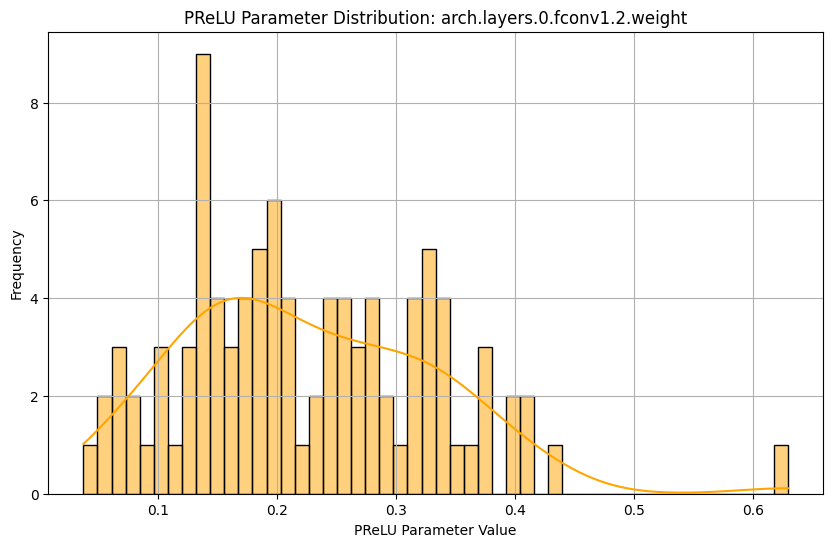

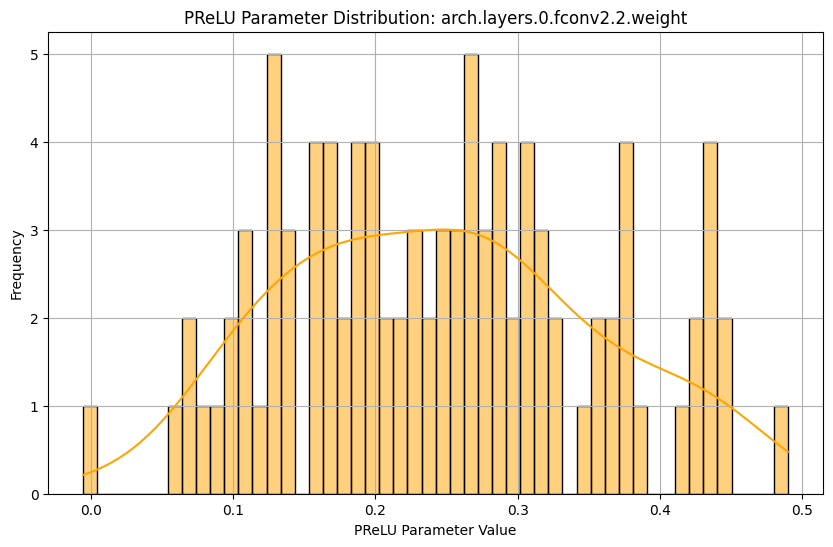

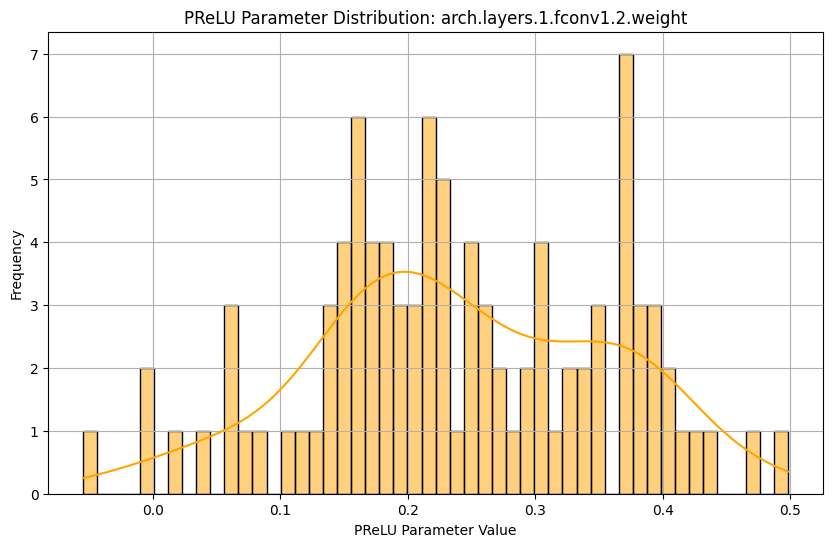

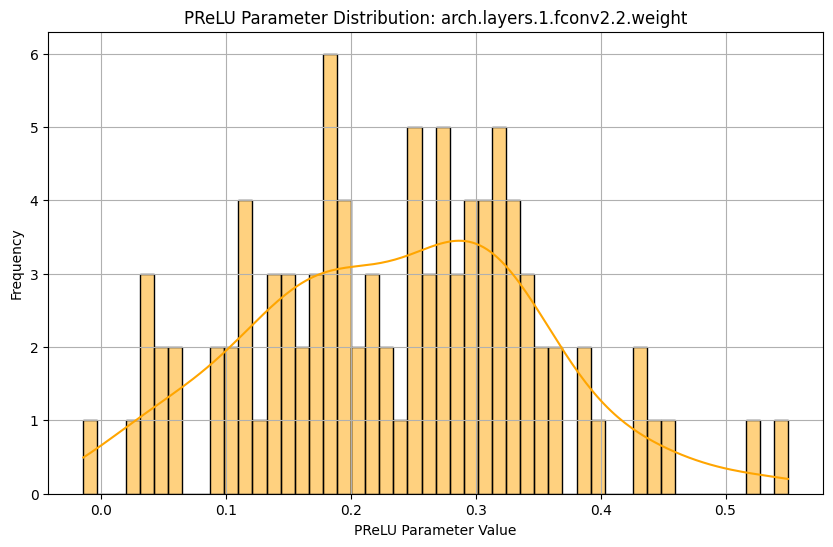

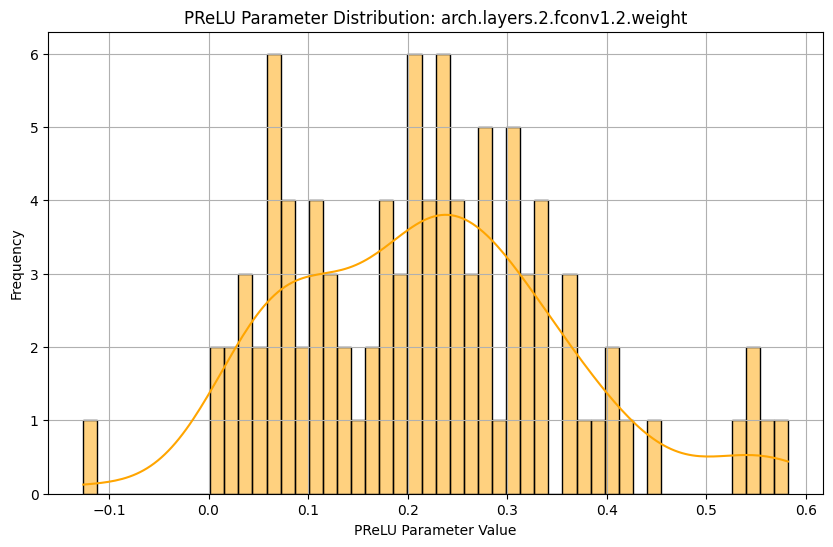

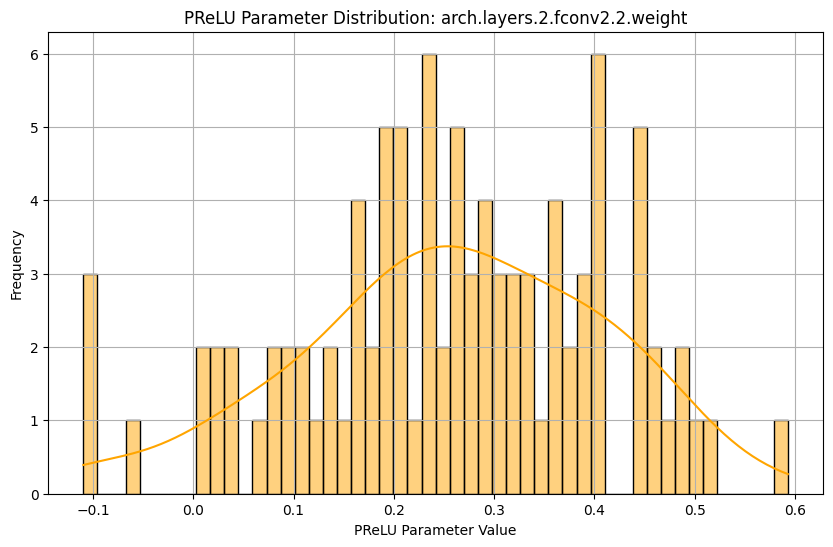

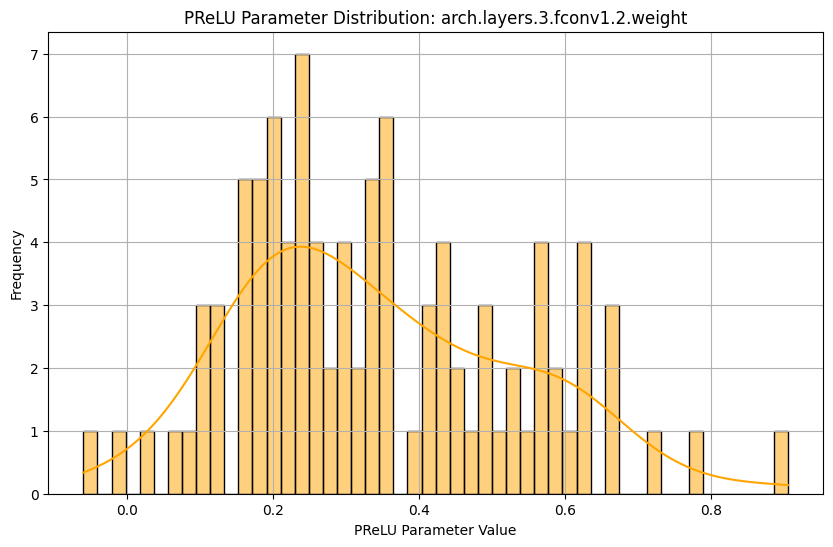

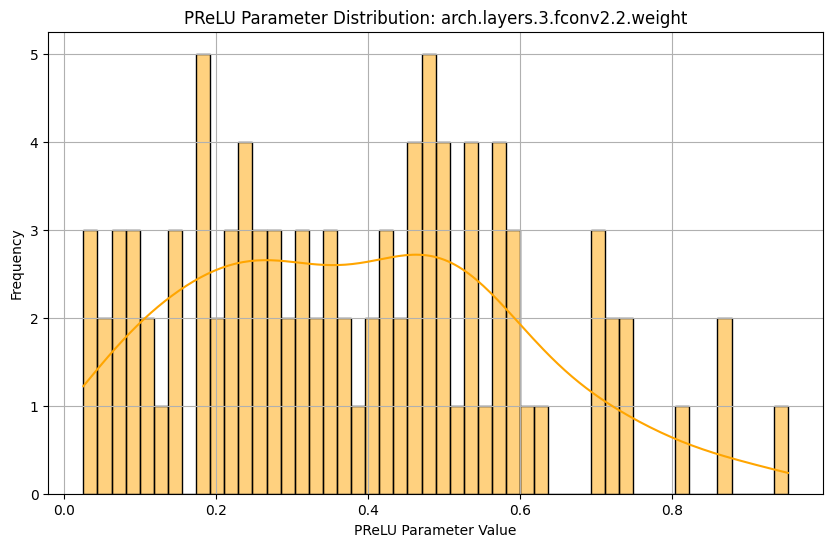

arch.layers.0.fconv1.2.weight: Mean=0.2252, Std=0.1054, Min=0.0372, Max=0.6293
arch.layers.0.fconv2.2.weight: Mean=0.2452, Std=0.1077, Min=-0.0052, Max=0.4900
arch.layers.1.fconv1.2.weight: Mean=0.2404, Std=0.1150, Min=-0.0544, Max=0.4981
arch.layers.1.fconv2.2.weight: Mean=0.2367, Std=0.1137, Min=-0.0140, Max=0.5499
arch.layers.2.fconv1.2.weight: Mean=0.2196, Std=0.1365, Min=-0.1257, Max=0.5819
arch.layers.2.fconv2.2.weight: Mean=0.2570, Std=0.1484, Min=-0.1096, Max=0.5929
arch.layers.3.fconv1.2.weight: Mean=0.3414, Std=0.1888, Min=-0.0604, Max=0.9059
arch.layers.3.fconv2.2.weight: Mean=0.3820, Std=0.2161, Min=0.0258, Max=0.9526


In [6]:
# Extract PReLU parameters
prelu_distributions = {}

for name, param in state_dict.items():
    if "fconv1.2.weight" in name or "fconv2.2.weight" in name:  # Match PReLU layers
        print(f"Found PReLU layer: {name}")
        prelu_distributions[name] = param.flatten().numpy()

# Plot PReLU parameter distributions
for name, prelu_params in prelu_distributions.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(prelu_params, bins=50, kde=True, color='orange')
    plt.title(f"PReLU Parameter Distribution: {name}")
    plt.xlabel("PReLU Parameter Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Print summary of PReLU parameters
for name, prelu_params in prelu_distributions.items():
    print(f"{name}: Mean={prelu_params.mean():.4f}, Std={prelu_params.std():.4f}, Min={prelu_params.min():.4f}, Max={prelu_params.max():.4f}")